# EDA

In [1]:
train_size = 0.70

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('imgs', exist_ok=True)


In [3]:
# if files are on drive
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/ai in industry/raw_sales.csv')
income = pd.read_csv('/content/drive/MyDrive/ai in industry/MEHOINUSA672N.csv')
mortgage = pd.read_csv('/content/drive/MyDrive/ai in industry/MORTGAGE15US.csv')

Mounted at /content/drive


In [4]:
# data = pd.read_csv('raw_sales.csv')
# mortgage = pd.read_csv('MORTGAGE15US.csv')
# income = pd.read_csv('MEHOINUSA672N.csv')
# data.head()

In [5]:
data.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [6]:
mortgage.head()

,observation_date,MORTGAGE15US
0,2007-02-08,6.02
1,2007-02-15,6.03
2,2007-02-22,5.97
3,2007-03-01,5.92
4,2007-03-08,5.86


In [7]:
income.head()

,observation_date,MEHOINUSA672N
0,2007-01-01,73010
1,2008-01-01,70520
2,2009-01-01,70070
3,2010-01-01,68420
4,2011-01-01,67410


In [8]:
# mortgage is weekly and income is yearly. make both of them monthly.
# for mortgage, average the weeks within each month; for income, forward fill the yearly value to all months.
mortgage['observation_date'] = pd.to_datetime(mortgage['observation_date'])
mortgage_monthly = (
    mortgage
    .set_index('observation_date')
    .resample('M')   # month-end
    .mean()
    .reset_index()
)

income['observation_date'] = pd.to_datetime(income['observation_date'])
income_monthly = (
    income
    .set_index('observation_date')
    .resample('M')   # month-end
    .ffill()
    .reset_index()
)

mortgage_monthly.head()

,observation_date,MORTGAGE15US
0,2007-02-28,6.006667
1,2007-03-31,5.884000
2,2007-04-30,5.882500
3,2007-05-31,5.968000
4,2007-06-30,6.340000


In [9]:
income_monthly.head()

,observation_date,MEHOINUSA672N
0,2007-01-31,73010
1,2007-02-28,73010
2,2007-03-31,73010
3,2007-04-30,73010
4,2007-05-31,73010


In [10]:
df = data.copy()
df = df.rename(columns={'datesold': 'date', 'propertyType': 'type'})
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,postcode,price,type,bedrooms
0,2007-02-07,2607,525000,house,4
1,2007-02-27,2906,290000,house,3
2,2007-03-07,2905,328000,house,3
3,2007-03-09,2905,380000,house,4
4,2007-03-21,2906,310000,house,3


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      29580 non-null  datetime64[ns]
 1   postcode  29580 non-null  int64         
 2   price     29580 non-null  int64         
 3   type      29580 non-null  object        
 4   bedrooms  29580 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 1.1+ MB


type
house    647956.128462
unit     423106.557279
Name: price, dtype: float64


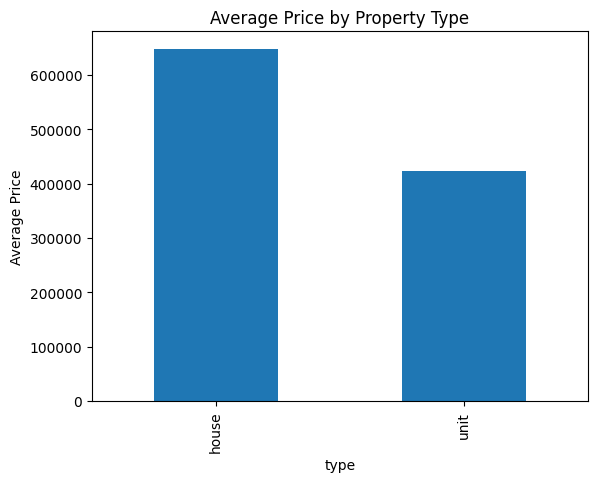

In [12]:
avg_price_by_type = df.groupby('type')['price'].mean().sort_values(ascending=False)
print(avg_price_by_type)
avg_price_by_type.plot(kind='bar', title='Average Price by Property Type')
plt.ylabel('Average Price')
plt.savefig('./imgs/avg_price_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

bedrooms
5    919056.058974
4    718171.142023
3    552304.428140
0    542300.000000
2    442222.917454
1    335992.905962
Name: price, dtype: float64


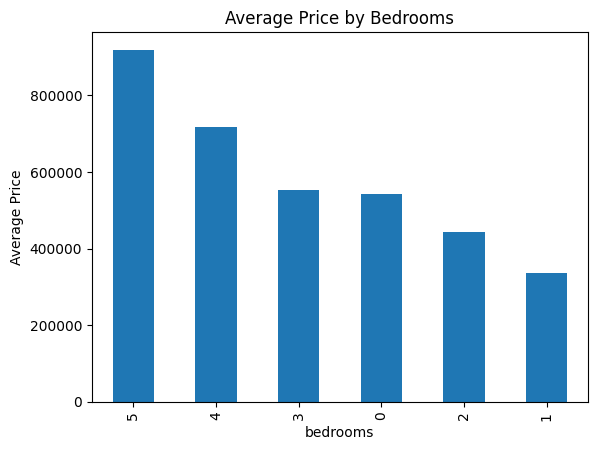

In [13]:
avg_price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_values(ascending=False)
print(avg_price_by_bedrooms)

avg_price_by_bedrooms.plot(kind='bar', title='Average Price by Bedrooms')
plt.ylabel('Average Price')
plt.savefig('./imgs/avg_price_by_bedrooms.png', dpi=150, bbox_inches='tight')
plt.show()

# MISSING VALUES

The number of bedrooms 0 can be considered as missing values, as it is unlikely that a property would have zero bedrooms. It is possible that these entries were either not recorded correctly. To handle these missing values, we can either impute them with a reasonable value (such as the mean number of bedrooms for that property type) or we can choose to drop those rows from the dataset if they are not significant in number.

In [14]:
#check for missing values
print(df.isnull().sum())

date        0
postcode    0
price       0
type        0
bedrooms    0
dtype: int64


In [15]:
# KNNImputer

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

def imputer_pipeline(df):

    df2 = df.copy()

    df2['bedrooms'] = df2['bedrooms'].replace(0, np.nan)

    le = LabelEncoder()
    df2['type_encoded'] = le.fit_transform(df2['type'])

    features = ['price', 'type_encoded', 'bedrooms']
    X = df2[features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    imputer = KNNImputer(n_neighbors=5, weights='distance')
    X_imputed = imputer.fit_transform(X_scaled)
    X_unscaled = scaler.inverse_transform(X_imputed)
    df2['bedrooms'] = X_unscaled[:, 2]

    df2['bedrooms'] = df2['bedrooms'].round().astype(int)
    df2['bedrooms'] = df2['bedrooms'].clip(lower=1, upper=5)
    df2['bedrooms'].value_counts()

    return df2

In [16]:
# print the different values that bedrooms assumes when type == 'unit'
print(df[df['type'] == 'unit']['bedrooms'].unique())

[2 3 1 0 4 5]


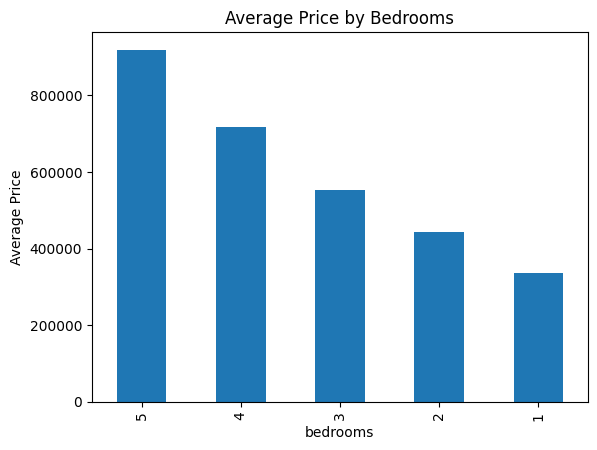

In [17]:
df = imputer_pipeline(df)

avg_price_by_bedrooms = df.groupby('bedrooms')['price'].mean().sort_values(ascending=False)

avg_price_by_bedrooms.plot(kind='bar', title='Average Price by Bedrooms')
plt.ylabel('Average Price')
plt.savefig('./imgs/avg_price_by_bedrooms_imputed.png', dpi=150, bbox_inches='tight')
plt.show()

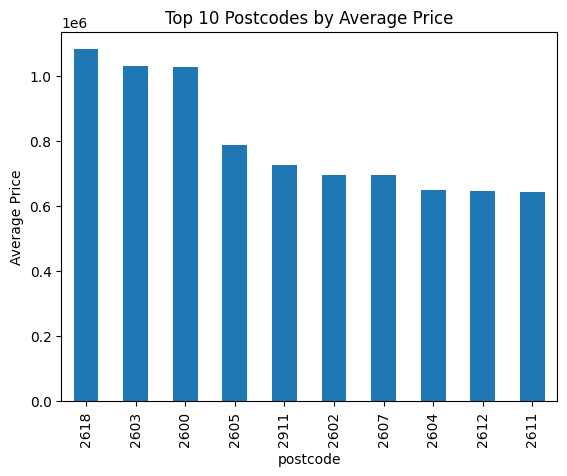

In [18]:
avg_price_by_postcode = df.groupby('postcode')['price'].mean().sort_values(ascending=False).head(10)

avg_price_by_postcode.plot(kind='bar', title='Top 10 Postcodes by Average Price')
plt.ylabel('Average Price')
plt.savefig('./imgs/top10_postcodes_avg_price.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
df.columns

Index(['date', 'postcode', 'price', 'type', 'bedrooms', 'type_encoded'], dtype='object')

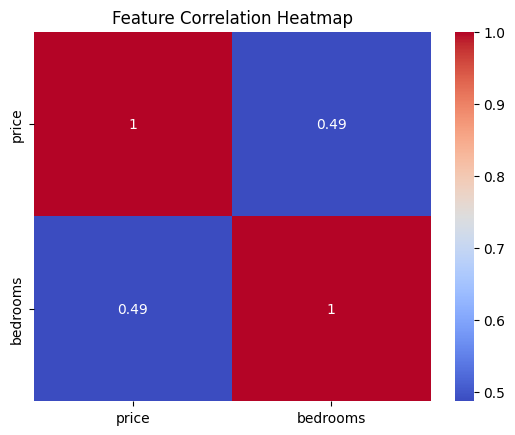

In [20]:
numeric_features = ['price', 'bedrooms']
sns.heatmap(df[numeric_features].corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('./imgs/feature_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

The fact that the correlation between price and bedrooms is 0.49 suggests that there is a moderate positive relationship between the two variables. This means that, in general, as the number of bedrooms increases, the price tends to increase as well. However, it is not a very strong correlation, indicating that there are other factors influencing the price of the properties besides just the number of bedrooms.

# OUTLIERS

In [21]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Outliers detected: {len(outliers)}")

Outliers detected: 1374


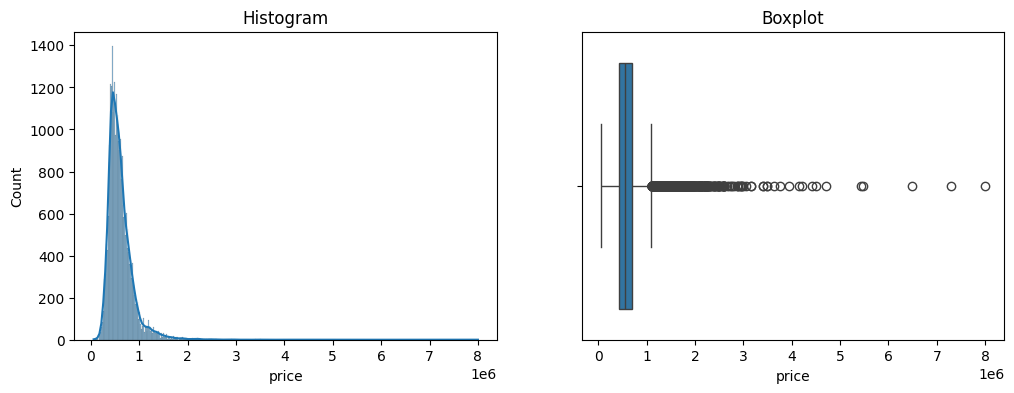

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_distribution(df, column):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df[column], kde=True, ax=ax[0])
    ax[0].set_title("Histogram")

    sns.boxplot(x=df[column], ax=ax[1])
    ax[1].set_title("Boxplot")

    plt.savefig(f'./imgs/distribution_{column}.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_distribution(df, 'price')

Since it's right skewed, we can apply a log transformation to the price variable to make it more normally distributed. This can help improve the performance of certain machine learning algorithms that assume normality in the data, such as linear regression. After applying the log transformation, we can visualize the distribution again to confirm that it has become more normal.

In [23]:
def plot_price_distribution(df):
    plt.figure(figsize=(10, 6))
    sns.histplot(df['price'], kde=True)
    plt.title('Distribution of Property Prices')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.savefig('./imgs/price_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_price_trend(monthly):
    plt.figure(figsize=(12, 6))
    plt.plot(monthly.index, monthly['price'], color='lightgray', label='Original', linewidth=1.5)
    plt.plot(monthly.index, monthly['price_rolling'], color='blue', label='Smoothed', linewidth=2)
    plt.title('Mean Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Mean Price')
    plt.legend()
    plt.tight_layout()
    plt.savefig('./imgs/price_trend.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_monthly_trend(monthly_df):
    monthly_df[['price', 'avg_bedrooms', 'house_ratio', 'sales_count']].plot(
        subplots=True, figsize=(10, 8), title='Monthly Trends')
    plt.tight_layout()
    plt.savefig('./imgs/monthly_trends.png', dpi=150, bbox_inches='tight')
    plt.show()

In [24]:
from sklearn.preprocessing import PowerTransformer

def pipeline(df, type_of_outlier, plotting=True):
    # Three strategies for right-skewed outliers:
    # 'none'            – keep data as-is
    # 'remove'          – drop rows outside IQR bounds
    # 'log_transform'   – apply log to price
    # 'power_transform' – Box-Cox transform

    if type_of_outlier == 'none':
        df_cleaned = df.copy()

    elif type_of_outlier == 'remove':
        Q1 = df['price'].quantile(0.25)
        Q3 = df['price'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_cleaned = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

    elif type_of_outlier == 'log_transform':
        df_cleaned = df.copy()
        df_cleaned['price'] = np.log(df_cleaned['price'])

    elif type_of_outlier == 'power_transform':
        df_cleaned = df.copy()
        pt = PowerTransformer(method='box-cox')
        df_cleaned['price'] = pt.fit_transform(df_cleaned[['price']])

    if plotting:
        plot_price_distribution(df_cleaned)

    monthly = df_cleaned.resample('M', on='date').agg({'price': 'mean'})
    monthly['price_rolling'] = monthly['price'].rolling(window=3, center=True).mean() # 3-month rolling average for smoothing

    if plotting:
        plot_price_trend(monthly)

    df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])
    df_cleaned['month'] = df_cleaned['date'].dt.to_period('M')

    monthly_df = (
        df_cleaned.groupby('month').agg(
            price=('price', 'mean'),
            house_ratio=('type', lambda x: (x == 'house').mean()),
            avg_bedrooms=('bedrooms', 'mean'),
            sales_count=('price', 'count')
        )
        .reset_index()
    )

    monthly_df['month'] = monthly_df['month'].dt.to_timestamp()
    monthly_df.set_index('month', inplace=True)

        # Merge macroeconomic monthly features (mortgage & income) into monthly_df if available
    try:
        macro_mortgage = mortgage_monthly.copy()
        macro_mortgage = macro_mortgage.rename(
            columns={
                'observation_date': 'month',
                'MORTGAGE15US': 'mortgage_rate'
            }
        )
        macro_mortgage['month'] = (
            pd.to_datetime(macro_mortgage['month'])
            .dt.to_period('M')
            .dt.to_timestamp()
        )
        macro_mortgage.set_index('month', inplace=True)

        macro_income = income_monthly.copy()
        macro_income = macro_income.rename(
            columns={
                'observation_date': 'month',
                'MEHOINUSA672N': 'median_income'
            }
        )
        macro_income['month'] = (
            pd.to_datetime(macro_income['month'])
            .dt.to_period('M')
            .dt.to_timestamp()
        )
        macro_income.set_index('month', inplace=True)

        macro = macro_mortgage.join(macro_income, how='outer')

        # join on the monthly index and forward-fill missing macro values
        monthly_df = monthly_df.join(
            macro[['mortgage_rate', 'median_income']],
            how='left'
        )
        monthly_df[['mortgage_rate', 'median_income']] = (
            monthly_df[['mortgage_rate', 'median_income']].ffill()
        )
    except NameError:
        # macro data not loaded, proceed without these features
        pass

    if plotting:
        plot_monthly_trend(monthly_df)

    return df_cleaned, monthly, monthly_df

df_cleaned, monthly, monthly_df = pipeline(df, type_of_outlier='remove', plotting=False)


The reason why we need house_ratio (house_ratio=('type', lambda x: (x == 'house').mean())) is to calculate the proportion of properties that are classified as 'house' within each month. This can provide insights into the distribution of property types over time and how it may relate to price trends. By including this ratio in our analysis, we can better understand the composition of the housing market and how it may influence mean prices.

# TRENDS AND SEASONALITY DECOMPOSITION

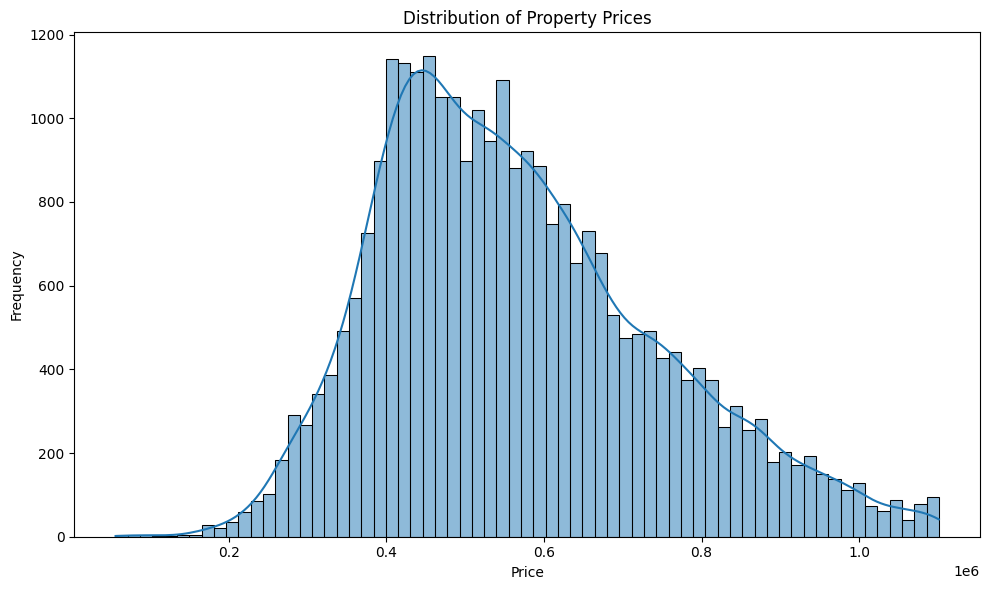

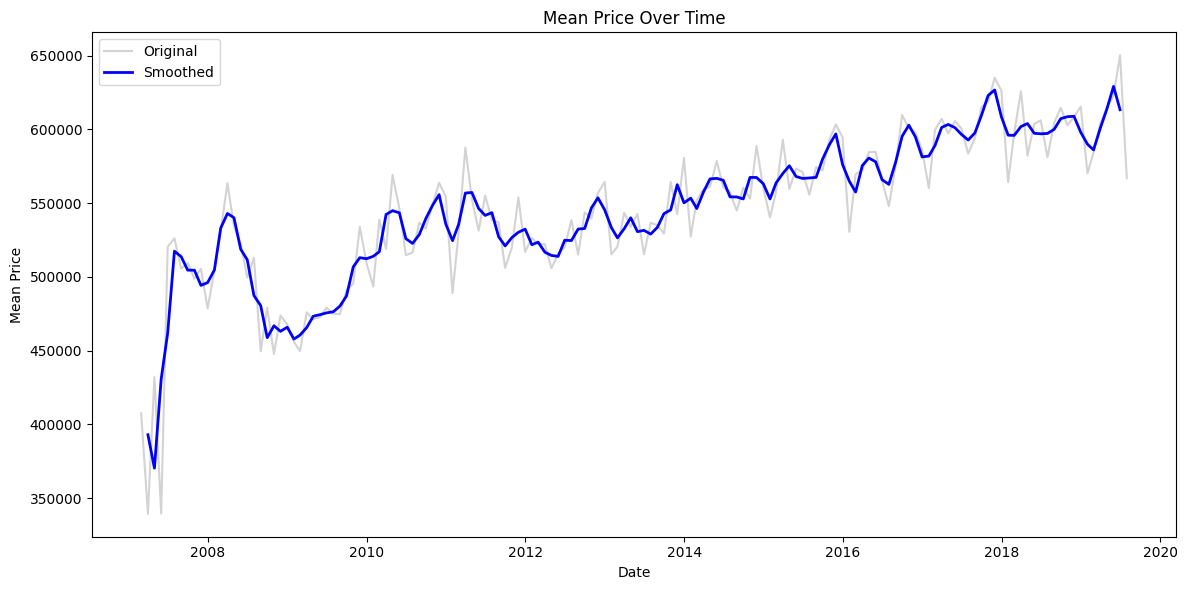

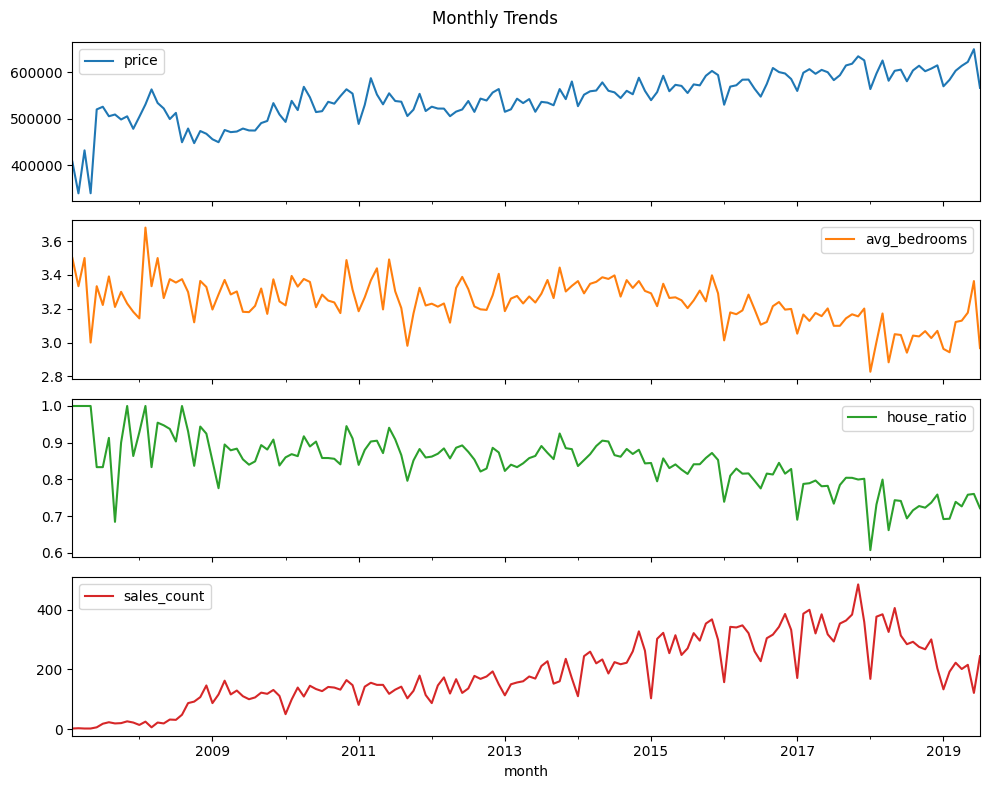

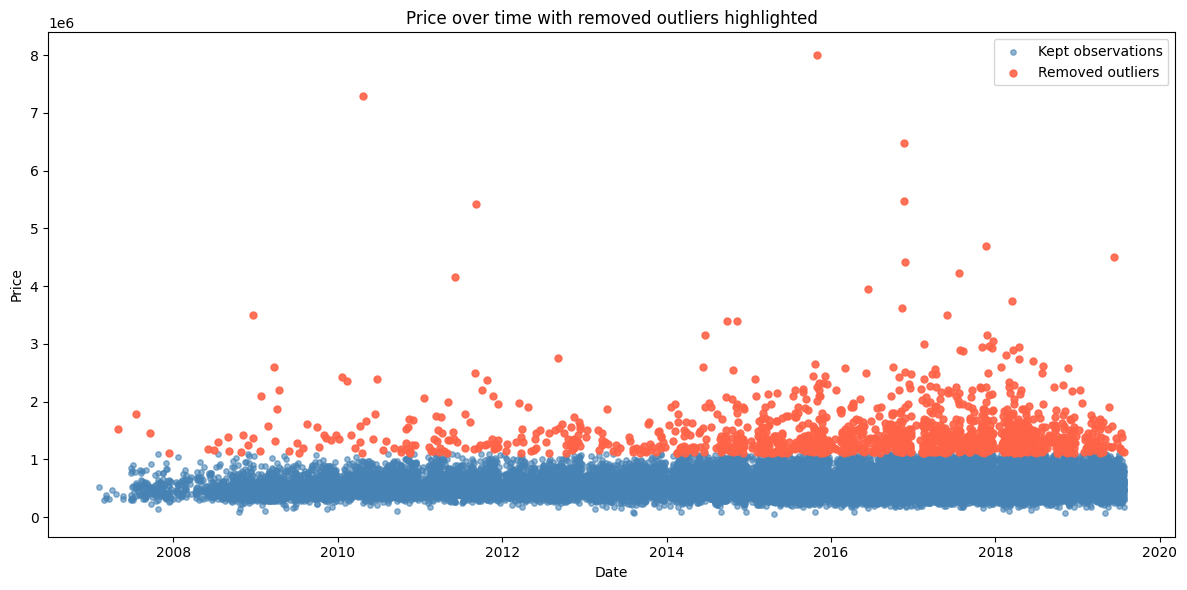

In [25]:
df_cleaned, monthly, monthly_df = pipeline(df, type_of_outlier='remove', plotting=True)

# Recompute the same IQR bounds used inside pipeline
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Points that were removed as outliers
mask_outlier = (df['price'] < lower_bound) | (df['price'] > upper_bound)
df_removed = df[mask_outlier]

# Time–price plot with different colours
plt.figure(figsize=(12, 6))

plt.scatter(
    df_cleaned['date'],
    df_cleaned['price'],
    s=15,
    alpha=0.6,
    color='steelblue',
    label='Kept observations',
)

plt.scatter(
    df_removed['date'],
    df_removed['price'],
    s=25,
    alpha=0.9,
    color='tomato',
    label='Removed outliers',
)

plt.title('Price over time with removed outliers highlighted')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.savefig('./imgs/price_over_time_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

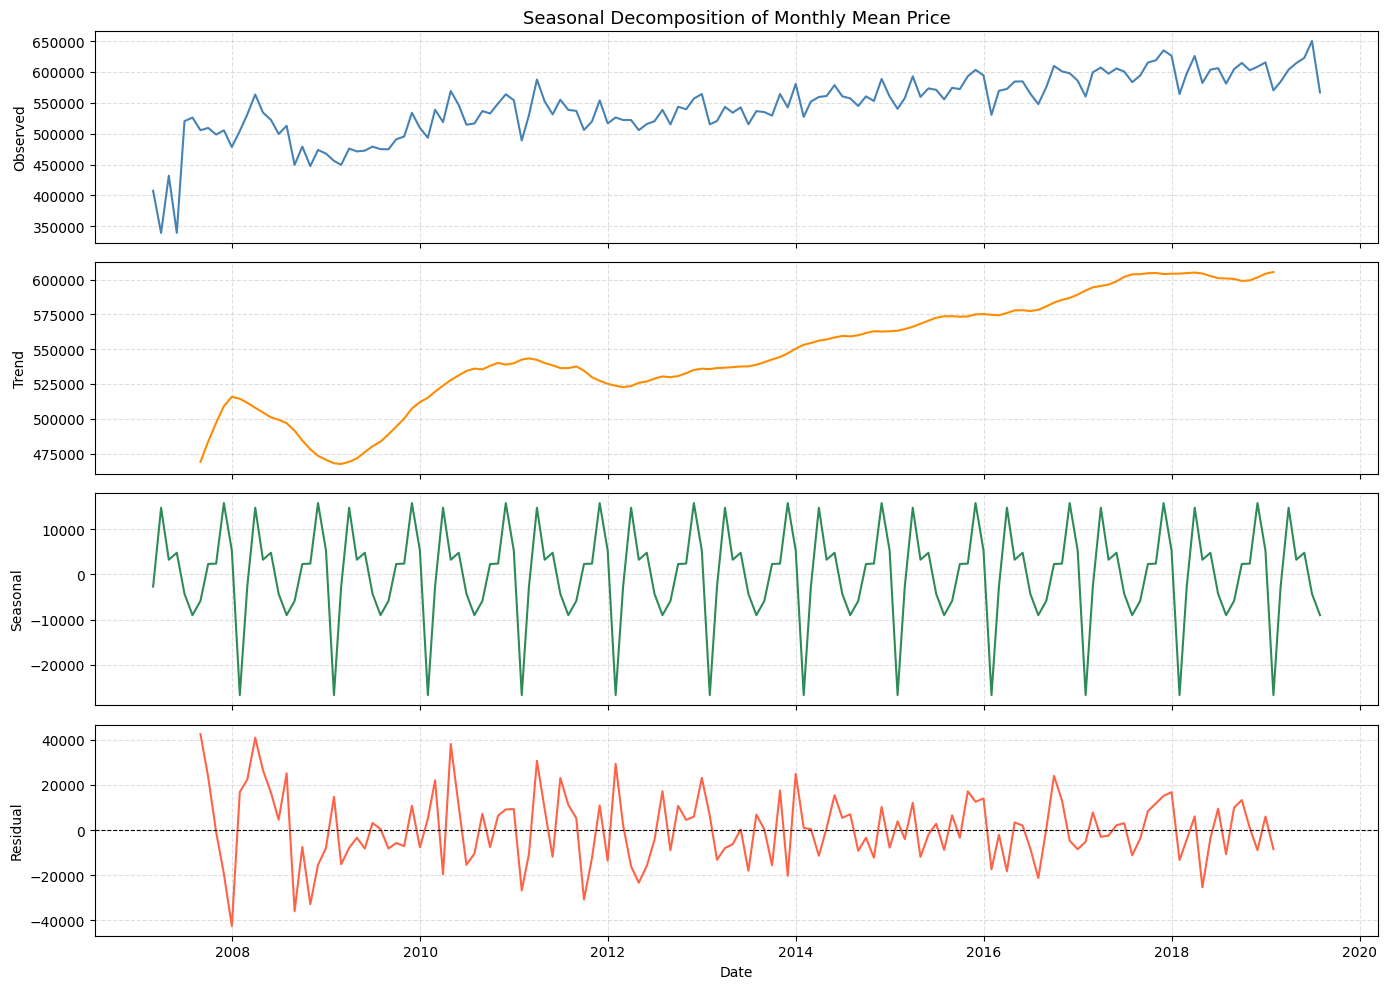

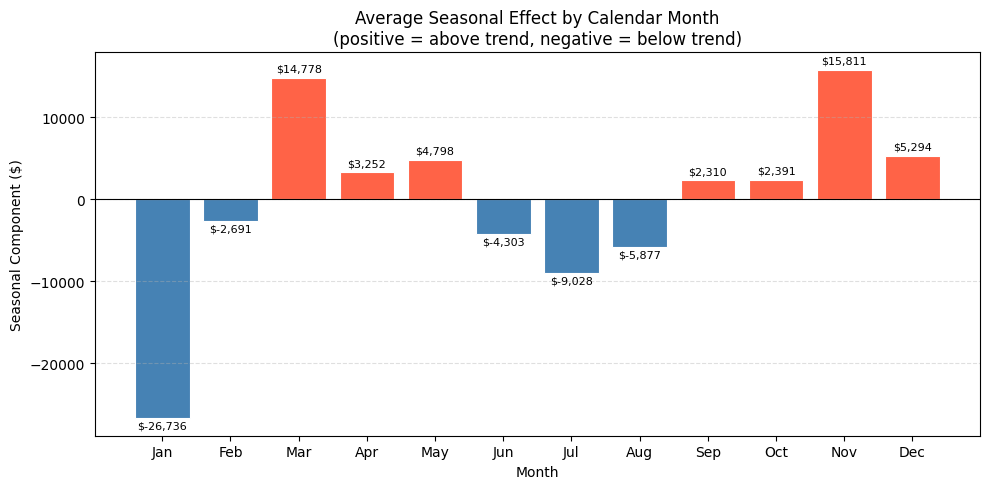

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose
import calendar

decomposition = seasonal_decompose(monthly['price'], model='additive', period=12)

# ── 1. Full decomposition plot (improved) ────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

components = {
    'Observed':  decomposition.observed,
    'Trend':     decomposition.trend,
    'Seasonal':  decomposition.seasonal,
    'Residual':  decomposition.resid,
}

colors = ['steelblue', 'darkorange', 'seagreen', 'tomato']

for ax, (name, series), color in zip(axes, components.items(), colors):
    ax.plot(series.index, series.values, color=color, linewidth=1.5)
    ax.set_ylabel(name, fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    if name == 'Residual':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

axes[0].set_title('Seasonal Decomposition of Monthly Mean Price', fontsize=13)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('./imgs/seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Average seasonal pattern by calendar month ────────────────────────────
seasonal_by_month = (
    decomposition.seasonal
    .groupby(decomposition.seasonal.index.month)
    .mean()
)
seasonal_by_month.index = [calendar.month_abbr[m] for m in seasonal_by_month.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    seasonal_by_month.index,
    seasonal_by_month.values,
    color=['tomato' if v > 0 else 'steelblue' for v in seasonal_by_month.values],
    edgecolor='white',
    linewidth=0.8,
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Seasonal Effect by Calendar Month\n(positive = above trend, negative = below trend)', fontsize=12)
ax.set_xlabel('Month')
ax.set_ylabel('Seasonal Component ($)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Annotate bars
for bar, val in zip(bars, seasonal_by_month.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + (500 if val >= 0 else -1500),
        f'${val:,.0f}',
        ha='center', va='bottom', fontsize=8
    )

plt.tight_layout()
plt.savefig('./imgs/seasonal_pattern_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

As we can see in our plot, most of the house prices range between $300,000 and $800,000.

There appears to be something interesting going on at the beginning of the time series plot. There is a very sharp peak around 2007 to 2008, with a major spike much higher than anything around it. This is in fact the observation with the highest price in the entire time series plot, reaching up to $800,000, so this is something of interest from the data. After doing some research, there was a major financial crisis which occurred from 2007 to 2008 which marked a huge economic recession. It would make sense that a big financial crisis like this would also have a significant effect on the housing market, so this is likely why there is such a sharp and sudden peak in home sale prices around 2007 to 2008.

There does appear to be some sort of seasonal trend going on within the data as seen by the various peaks and drops that can be seen within the plot. This shows evidence of some sort of seasonality occurring. This seasonal pattern appears to repeat over each year, with the highest and lowest peaks occurring within the span of each year period.

A seasonal trend would make sense for a data set relating to house sale prices as the time of year could affect the number of individuals buying a new home, and thus sale prices rising to meet this larger demand. For instance, times of year such as the summer may see an increase of buyers looking for a new house due to the ideal weather and the timing of summer break making it ideal to buy a house before the next school year begins if the buyers have children. This greater demand could lead to a rise in the sales prices of the homes, and could be a potential explanation for this seasonal trend we see in the time series plot.

Additionally, there appears to be an overall increase in home sale prices from 2007 to 2019. Looking at the trend curve, we can see that there has been an overall, gradual increase in the home sale prices from the start of this data set’s collection to the end of its collection. So, we can conclude that the home sale prices have gradually increased from what they were in 2007 to what they became in 2019.

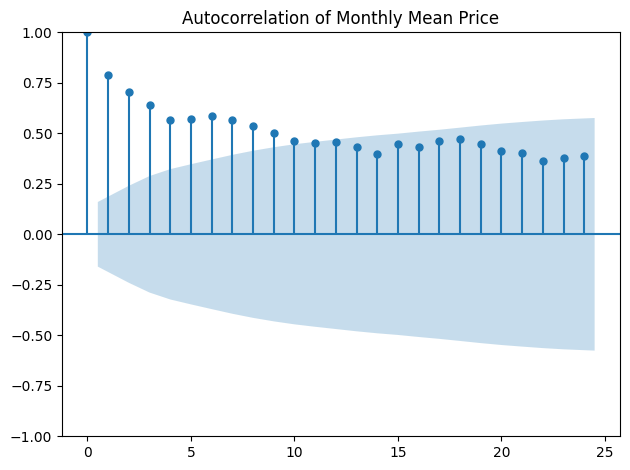

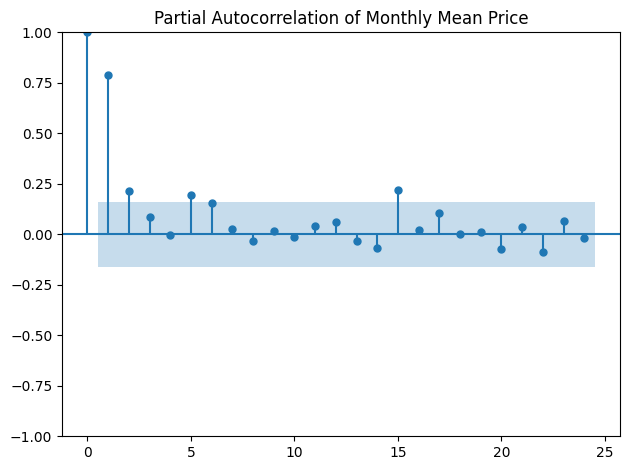

In [27]:
# plot autocorrelation and partial autocorrelation
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(monthly['price'].dropna(), lags=24)
plt.title('Autocorrelation of Monthly Mean Price')
plt.tight_layout()
plt.savefig('./imgs/acf.png', dpi=150, bbox_inches='tight')
plt.show()
plot_pacf(monthly['price'].dropna(), lags=24)
plt.title('Partial Autocorrelation of Monthly Mean Price')
plt.tight_layout()
plt.savefig('./imgs/pacf.png', dpi=150, bbox_inches='tight')
plt.show()

**Strong Trend (Non-Stationarity)**: The most prominent feature is the slow, gradual decay of the autocorrelation values starting from lag 0. This is a textbook signature of a non-stationary time series with a strong underlying trend. It means the price in any given month is heavily tethered to the prices in the immediately preceding months.

**Significant Lags: The shaded blue cone represents the confidence interval. Any point (stem) that falls outside this cone is statistically significant. Lags 1 through roughly 9 remain above the blue area, indicating that historical prices up to 9 months back have a mathematically significant relationship with the current price.

In [28]:
monthly_df.head(20)

,price,house_ratio,avg_bedrooms,sales_count,mortgage_rate,median_income
month,,,,,,
2007-02-01,407500.000000,1.000000,3.500000,2,6.006667,73010.0
2007-03-01,339333.333333,1.000000,3.333333,3,5.884000,73010.0
2007-04-01,432000.000000,1.000000,3.500000,2,5.882500,73010.0
2007-05-01,339500.000000,1.000000,3.000000,2,5.968000,73010.0
2007-06-01,520333.333333,0.833333,3.333333,6,6.340000,73010.0
2007-07-01,526083.333333,0.833333,3.222222,18,6.360000,73010.0
2007-08-01,505608.695652,0.913043,3.391304,23,6.234000,73010.0
2007-09-01,509342.105263,0.684211,3.210526,19,6.047500,73010.0
2007-10-01,498600.000000,0.900000,3.300000,20,6.040000,73010.0


# GEOGRAPHIC ANALYSIS

In [29]:
# print average house price vs average unit price
avg_price_by_type = df.groupby('type')['price'].mean()
print(avg_price_by_type)

type
house    647956.128462
unit     423106.557279
Name: price, dtype: float64


In [30]:
# Calculate the historical average price per postcode
zone_prices = df.groupby('postcode')['price'].mean().sort_values(ascending=False)

# Define 'Premium' zones (e.g., top 25% of postcodes by price)
premium_cutoff = zone_prices.quantile(0.65)
premium_postcodes = zone_prices[zone_prices >= premium_cutoff].index.tolist()

# Create a 'is_premium_zone' feature
df['is_premium_zone'] = df['postcode'].isin(premium_postcodes).astype(int)

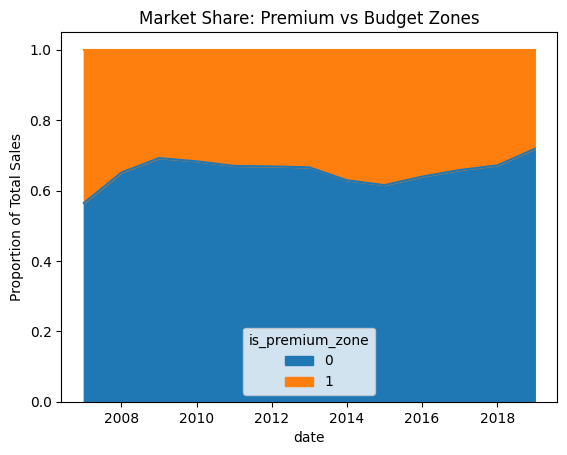

In [31]:
# Group by year and zone type to see volume trends
zone_trends = df.groupby([df['date'].dt.year, 'is_premium_zone']).size().unstack()
zone_trends_pct = zone_trends.div(zone_trends.sum(axis=1), axis=0)

zone_trends_pct.plot(kind='area', stacked=True, title='Market Share: Premium vs Budget Zones')
plt.ylabel('Proportion of Total Sales')
plt.savefig('./imgs/market_share_premium_budget.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# 1. Calculate the historical mean price per postcode to identify expensive areas
postcode_stats = df.groupby('postcode')['price'].mean().sort_values(ascending=False)

# 2. Define 'Premium' zones as the top 25% most expensive postcodes
premium_cutoff = postcode_stats.quantile(0.75)
premium_postcodes = postcode_stats[postcode_stats >= premium_cutoff].index.tolist()

# 3. Tag each sale in the main dataframe
df['zone_type'] = df['postcode'].apply(lambda x: 'Premium' if x in premium_postcodes else 'Budget')

print(f"Premium Zone Cutoff: ${premium_cutoff:,.0f}")
print(f"Number of Premium Postcodes: {len(premium_postcodes)}")

Premium Zone Cutoff: $671,179
Number of Premium Postcodes: 7


In [33]:
# Create a 'year' column for grouping
df['year'] = df['date'].dt.year

# Calculate volume share per year per zone
zone_distribution = df.groupby(['year', 'zone_type']).size().unstack().fillna(0)

# Convert to percentages (normalized)
zone_share_pct = zone_distribution.divide(zone_distribution.sum(axis=1), axis=0) * 100

# Display the trend table
print(zone_share_pct.tail())

zone_type     Budget    Premium
year                           
2015       76.781798  23.218202
2016       78.659161  21.340839
2017       79.938340  20.061660
2018       81.855884  18.144116
2019       83.104693  16.895307


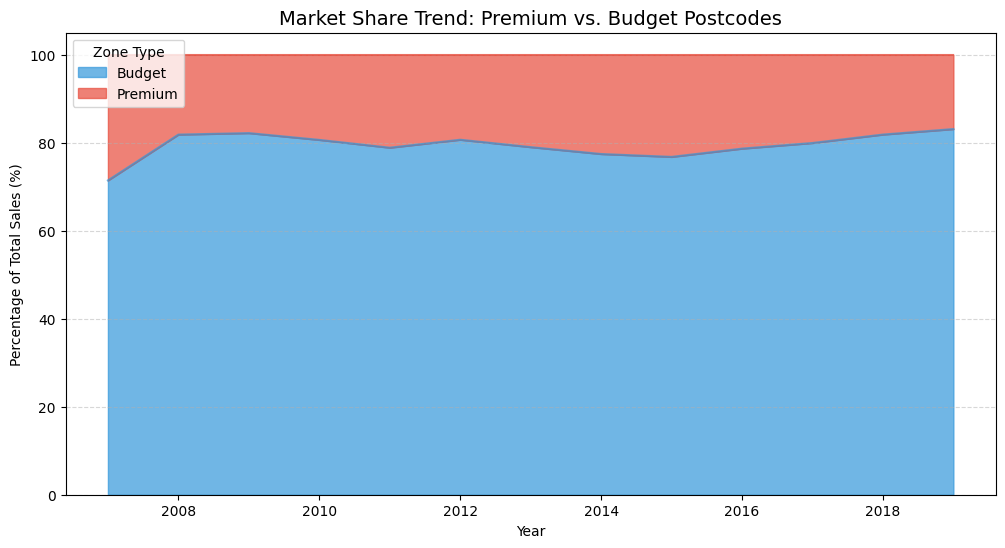

In [34]:
plt.figure(figsize=(12, 6))
zone_share_pct.plot(kind='area', stacked=True, color=['#3498db', '#e74c3c'], alpha=0.7, ax=plt.gca())

plt.title('Market Share Trend: Premium vs. Budget Postcodes', fontsize=14)
plt.ylabel('Percentage of Total Sales (%)')
plt.xlabel('Year')
plt.legend(title='Zone Type', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig('./imgs/market_share_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# MEAN PRICE BY MONTH FORECAST WITH ML MODELS

## Seasonality Feature Engineering

Before fitting any model, we enrich `monthly_df` with three new columns that encode temporal patterns:

- **`month_sin` / `month_cos`** — Cyclical encoding of the month number.  
  A raw integer (1–12) would imply that December and January are 11 steps apart, when they are actually adjacent.  
  Projecting onto the unit circle (`sin(2π·m/12)`, `cos(2π·m/12)`) preserves the cyclic structure and uniquely identifies every month.

- **`year_scaled`** — Mean-centred, unit-variance year. Captures the long-run upward price trend without dominating gradient-based optimisers (important for the LSTM).

In [35]:
def add_seasonality_features(monthly_df: pd.DataFrame) -> pd.DataFrame:
    """
    Append cyclical month encoding and scaled year to a monthly DatetimeIndex DataFrame.
    - month_sin / month_cos : encode the cyclic structure of the 12-month calendar
    - year_scaled           : linear trend proxy (zero-mean, unit-variance)
    """
    df = monthly_df.copy()
    month = df.index.month
    # Convert to a NumPy array so mean/std are always available
    year  = np.asarray(df.index.year, dtype=float)

    df['month_sin']   = np.sin(2 * np.pi * month / 12)
    df['month_cos']   = np.cos(2 * np.pi * month / 12)
    year_mean = year.mean()
    year_std  = year.std() if year.std() != 0 else 1.0
    df['year_scaled'] = (year - year_mean) / year_std
    return df

# Quick sanity check
_,_,_tmp = pipeline(df, type_of_outlier='remove', plotting=False)
print(add_seasonality_features(_tmp).head())

                    price  house_ratio  avg_bedrooms  sales_count  \
month                                                               
2007-02-01  407500.000000     1.000000      3.500000            2   
2007-03-01  339333.333333     1.000000      3.333333            3   
2007-04-01  432000.000000     1.000000      3.500000            2   
2007-05-01  339500.000000     1.000000      3.000000            2   
2007-06-01  520333.333333     0.833333      3.333333            6   

            mortgage_rate  median_income     month_sin     month_cos  \
month                                                                  
2007-02-01       6.006667        73010.0  8.660254e-01  5.000000e-01   
2007-03-01       5.884000        73010.0  1.000000e+00  6.123234e-17   
2007-04-01       5.882500        73010.0  8.660254e-01 -5.000000e-01   
2007-05-01       5.968000        73010.0  5.000000e-01 -8.660254e-01   
2007-06-01       6.340000        73010.0  1.224647e-16 -1.000000e+00   

           

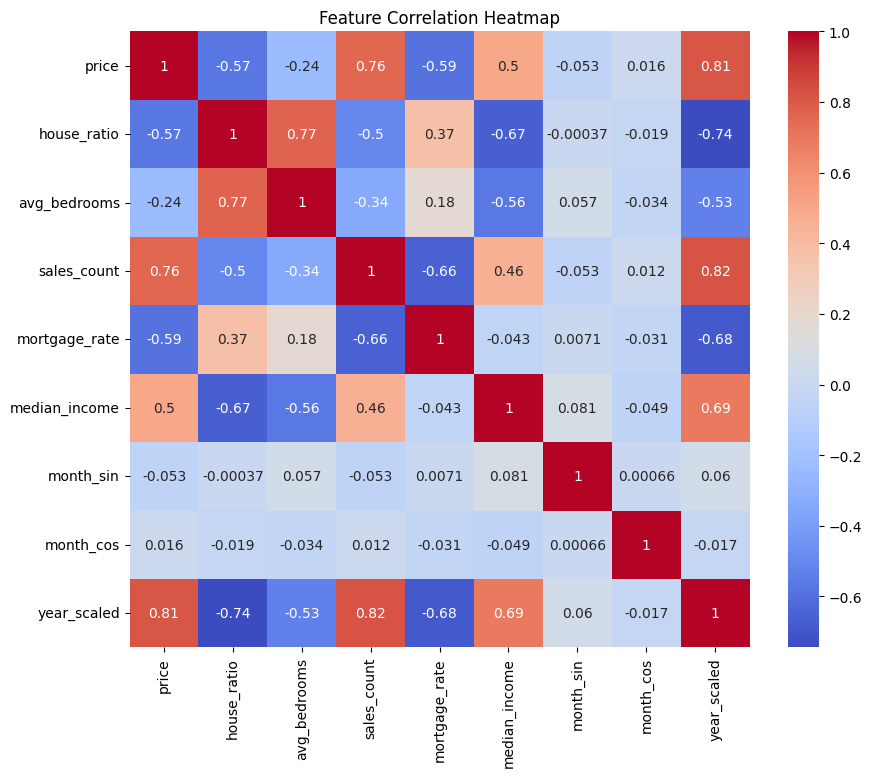

In [36]:
# let's check the correlation of the new features with price
_,_,monthly_df = pipeline(df, type_of_outlier='remove', plotting=False)
monthly_df = add_seasonality_features(monthly_df)
numeric_features = [
    'price',
    'house_ratio',
    'avg_bedrooms',
    'sales_count',
    'mortgage_rate',
    'median_income',
    'month_sin',
    'month_cos',
    'year_scaled',
]

plt.figure(figsize=(10, 8))
plt.title('Feature Correlation Heatmap')
sns.heatmap(monthly_df[numeric_features].corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.savefig('./imgs/feature_correlation_heatmap_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

### Random Forest Regressor

In [56]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import shap

def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


feats = {
    'seasonality': [
        'month_sin', 'month_cos', 'year_scaled',
        'avg_bedrooms', 'house_ratio', 'sales_count',
        'mortgage_rate', 'median_income',
    ],
    'non-seasonality': [
        'avg_bedrooms', 'house_ratio', 'sales_count',
        'mortgage_rate', 'median_income',
    ],
}


def random_forest_evaluation_pipeline( types_of_outlier=('none', 'remove', 'log_transform'),
    seasonality=True,
    plot=True,):

    # Always evaluate non-seasonal features; optionally also seasonal ones
    feature_sets = [('non-seasonality', feats['non-seasonality'])]
    if seasonality:
        feature_sets.append(('seasonality', feats['seasonality']))

    for type_of_outlier in types_of_outlier:
        for feat_name, feature_cols in feature_sets:
            print(f"\n--- Random Forest | outlier method: {type_of_outlier} | features: {feat_name} ---")

            # 1. Build pipeline data and add seasonality
            df_cleaned, monthly, monthly_df_cleaned = pipeline(df, type_of_outlier=type_of_outlier, plotting=False)
            monthly_df_season = add_seasonality_features(monthly_df_cleaned)

            # 2. Train / test split
            split_idx = int(len(monthly_df_season) * train_size)
            train = monthly_df_season.iloc[:split_idx]
            test = monthly_df_season.iloc[split_idx:]

            X_train = train[feature_cols]
            y_train = train['price']
            X_test = test[feature_cols]
            y_test = test['price']

            # 3. Fit model
            model_rf = RandomForestRegressor(n_estimators=200, random_state=42)
            model_rf.fit(X_train, y_train)
            predictions = model_rf.predict(X_test)

            # 4. Inverse-transform to dollars
            if type_of_outlier == 'log_transform':
                actual_dollar = np.exp(y_test.values)
                preds_dollar = np.exp(predictions)
                history_dollar = np.exp(monthly_df_season['price'].values)
            else:
                actual_dollar = y_test.values
                preds_dollar = predictions
                history_dollar = monthly_df_season['price'].values

            # 5. RMSE
            rmse_rf = calculate_rmse(actual_dollar, preds_dollar)
            print(f"Random Forest RMSE: ${rmse_rf:,.2f}")

            # 6. Forecast plot
            if plot:
                full_dates = monthly_df_season.index
                test_dates = test.index

                plt.figure(figsize=(12, 6))
                plt.plot(full_dates, history_dollar, label='Actual History', color='lightgray', linewidth=2)
                plt.plot(test_dates, actual_dollar, label='Actual Test', color='black', linewidth=2)
                plt.plot(
                    test_dates,
                    preds_dollar,
                    label=f'RF (RMSE=${int(rmse_rf):,})',
                    color='tomato',
                    linestyle='--',
                    linewidth=2,
                )
                plt.title(f'Random Forest Predictions vs Actuals  (method: {type_of_outlier}, features: {feat_name})')
                plt.xlabel('Date')
                plt.ylabel('Price ($)')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.savefig(f'./imgs/rf_forecast_{type_of_outlier}_{feat_name}.png', dpi=150, bbox_inches='tight')
                plt.show()

                # 7. Feature importance
                importance = pd.Series(
                    model_rf.feature_importances_,
                    index=feature_cols,
                ).sort_values(ascending=False)
                print(f"Feature importances:\n{importance.round(4)}\n")

                plt.figure(figsize=(8, 4))
                sns.barplot(x=importance.values, y=importance.index, palette='viridis')
                plt.title(f'RF Feature Importance  (method: {type_of_outlier}, features: {feat_name})')
                plt.xlabel('Importance Score')
                plt.tight_layout()
                plt.savefig(f'./imgs/rf_importance_{type_of_outlier}_{feat_name}.png', dpi=150, bbox_inches='tight')
                plt.show()

                # 8. SHAP
                explainer = shap.TreeExplainer(model_rf)
                shap_values = explainer.shap_values(X_test)

                plt.figure()
                shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
                plt.title(f'SHAP Mean |value| per feature  (method: {type_of_outlier}, features: {feat_name})')
                plt.tight_layout()
                plt.savefig(f'./imgs/rf_shap_bar_{type_of_outlier}_{feat_name}.png', dpi=150, bbox_inches='tight')
                plt.show()

                plt.figure()
                shap.summary_plot(shap_values, X_test, show=False)
                plt.title(f'SHAP Beeswarm  (method: {type_of_outlier}, features: {feat_name})')
                plt.tight_layout()
                plt.savefig(f'./imgs/rf_shap_beeswarm_{type_of_outlier}_{feat_name}.png', dpi=150, bbox_inches='tight')
                plt.show()

**Feature importance note:** The three original features (`sales_count`, `avg_bedrooms`, `house_ratio`) remain the dominant predictors.  
The seasonality features (`month_sin`, `month_cos`, `year_scaled`) should absorb some of the variance that was previously captured implicitly by `sales_count` (which itself is seasonal), potentially improving generalisation.  
The SHAP beeswarm additionally shows the *direction* of each feature's effect: positive SHAP values push the predicted price up, negative values push it down.

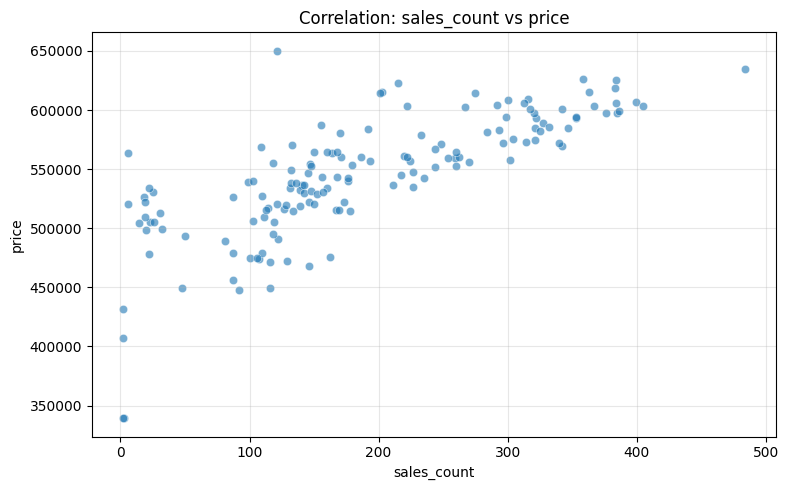

In [38]:
# Correlation scatter plots (fix: save BEFORE show)
df_corr, _, monthly_corr = pipeline(df, type_of_outlier='remove', plotting=False)
monthly_corr_season = add_seasonality_features(monthly_corr)

def plot_correlation(df, feature, target='price'):
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=df[feature], y=df[target], alpha=0.6)
    plt.title(f'Correlation: {feature} vs {target}')
    plt.xlabel(feature); plt.ylabel(target)
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f'./imgs/correlation_random_forest_{feature}_{target}.png', dpi=150, bbox_inches='tight')  # save BEFORE show
    plt.show()

for feat in ['sales_count']:# 'avg_bedrooms', 'house_ratio', 'month_sin', 'month_cos', 'year_scaled']:
    plot_correlation(monthly_corr_season, feat, target='price')

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

import shap


# ============================================================
# Utility
# ============================================================

def calculate_rmse(y_true, y_pred):
    """Root Mean Squared Error in natural price units."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def add_price_lags(df, lags=(1, 12)):
    """
    Create lagged price features.
    These are SAFE because they only use past information.
    """
    df = df.copy()
    for lag in lags:
        df[f"price_lag_{lag}"] = df["price"].shift(lag)
    return df


# ============================================================
# Feature dictionary (you can change when calling function)
# ============================================================

FEATURE_SETS = {
    # Safe long-term forecasting (only calendar, no market variables)
    "known_future": [
        "month_sin",
        "month_cos",
        "year_scaled",
    ],

    "lags": [
        "price_lag_1",
        "price_lag_12",
    ],

    # Market features that may be unknown in the future
    "all": [
        "month_sin",
        "month_cos",
        "year_scaled",
        "avg_bedrooms",
        "house_ratio",
        "sales_count",
        "price_lag_1",
        "price_lag_12",
    ],

    # Everything
    "all_and_macro": [
        "month_sin",
        "month_cos",
        "year_scaled",
        "avg_bedrooms",
        "house_ratio",
        "sales_count",
        "mortgage_rate",
        "median_income",
        "price_lag_1",
        "price_lag_12",
    ],
}


# ============================================================
# MAIN PIPELINE
# ============================================================

def random_forest_evaluation_pipeline(
    df,
    pipeline_function,
    add_seasonality_function,
    train_size=0.8,
    feature_dict=FEATURE_SETS,
    feature_keys=FEATURE_SETS.keys(),
    outlier_methods=("none",),
    use_lags=True,
    lag_values=(1, 12),
    plot=True,
    use_shap=False,
    grid_search=False,
    rf_params=None,
):
    """
    FULLY PARAMETRIC RANDOM FOREST PIPELINE.

    Parameters
    ----------
    df : DataFrame
        Original raw dataset.

    pipeline_function : function
        Your cleaning pipeline(df, type_of_outlier, plotting=False)

    add_seasonality_function : function
        Function that adds sin/cos/month/year features.

    feature_dict : dict
        Dictionary mapping feature-set names to column lists.

    feature_keys : list
        Which feature sets to evaluate.

    use_lags : bool
        If True, adds lagged price features (safe autoregressive).

    grid_search : bool
        If True, runs GridSearchCV to tune RF hyperparameters.

    plot : bool
        Plot forecasts + feature importance.

    use_shap : bool
        Run SHAP explainability (slow).
    """

    # Default RF parameters
    if rf_params is None:
        rf_params = {
            "n_estimators": 300,
            "max_depth": None,
            "random_state": 42,
            "n_jobs": -1,
        }

    # Optional grid search space
    grid_params = {
        "n_estimators": range(100, 501, 100),
        "max_depth": range(5, 16, 5),
        "min_samples_split": [2, 3, 4, 5],
    }

    # ========================================================
    # LOOP over outlier methods and feature sets
    # ========================================================

    for outlier in outlier_methods:
        for key in feature_keys:

            print("\n" + "=" * 60)
            print(f"RF | Outlier: {outlier} | Features: {key}")
            print("=" * 60)

            # --------------------------------------------
            # 1. Run data pipeline
            # --------------------------------------------
            df_cleaned, monthly, monthly_df = pipeline_function(
                df,
                type_of_outlier=outlier,
                plotting=False,
            )

            # Add seasonality features
            monthly_df = add_seasonality_function(monthly_df)

            # Add lagged prices if requested
            if use_lags:
                monthly_df = add_price_lags(monthly_df, lag_values)

            # Drop rows with NaN from lags
            monthly_df = monthly_df.dropna()

            feature_cols = feature_dict[key]

            # --------------------------------------------
            # 2. Train / Test split (time-series safe)
            # --------------------------------------------
            split_idx = int(len(monthly_df) * train_size)

            train = monthly_df.iloc[:split_idx]
            test = monthly_df.iloc[split_idx:]

            X_train = train[feature_cols]
            y_train = train["price"]

            y_test = test["price"]

            # --------------------------------------------
            # 3. Train model
            # --------------------------------------------
            model_rf = RandomForestRegressor(**rf_params)
            if grid_search:
                print("Running GridSearchCV...")
                model = GridSearchCV(
                    RandomForestRegressor(random_state=42),
                    grid_params,
                    cv=3,
                    n_jobs=-1,
                )
                model.fit(X_train, y_train)
                model_rf = model.best_estimator_
                print("Best params:", model.best_params_)
            else:
                model_rf.fit(X_train, y_train)

            # --------------------------------------------
            # 4. Recursive prediction for lagged features (FIX for data leakage)
            # --------------------------------------------
            # Identify which features are lagged prices
            lagged_price_features = [f for f in feature_cols if f.startswith("price_lag_")]
            exog_features_only = [f for f in feature_cols if not f.startswith("price_lag_")]

            preds = []

            if lagged_price_features:
                # Initialize history for lags with training actuals
                history_for_lags = list(y_train.values)

                # Ensure history_for_lags is sufficiently long to cover the largest lag needed
                # (This padding is a safeguard, monthly_df.dropna() should handle most of this)
                max_lag_val = max([int(f.split('_')[-1]) for f in lagged_price_features])
                if len(history_for_lags) < max_lag_val:
                    # Pad with the last available training price or mean to avoid index errors
                    padding_needed = max_lag_val - len(history_for_lags)
                    history_for_lags = [history_for_lags[-1]] * padding_needed + history_for_lags


                # For each step in the test set, make a recursive prediction
                for i in range(len(test)):
                    # Create a dictionary to hold features for the current prediction step
                    current_features_dict = {}

                    # Populate exogenous features from the test set
                    for f in exog_features_only:
                        current_features_dict[f] = test.iloc[i][f]

                    # Populate lagged price features using the recursive history
                    for lag_col_name in lagged_price_features:
                        lag_value = int(lag_col_name.split('_')[-1])
                        current_features_dict[lag_col_name] = history_for_lags[-lag_value]

                    # Convert to DataFrame, ensuring correct column order for prediction
                    X_input_for_pred = pd.DataFrame([current_features_dict], columns=X_train.columns)

                    # Predict the current step
                    current_pred = model_rf.predict(X_input_for_pred)[0]
                    preds.append(current_pred)

                    # Update history_for_lags with the new prediction for the next iteration
                    history_for_lags.append(current_pred)
            else:
                # If no lags, direct prediction is fine.
                # X_test was never explicitly created in this branch, so create it here
                X_test_direct = test[feature_cols]
                preds = model_rf.predict(X_test_direct)

            # Convert to numpy array for consistency with other parts of the pipeline
            preds = np.array(preds)

            # --------------------------------------------
            # 5. Inverse transform if log prices
            # --------------------------------------------
            if outlier == "log_transform":
                actual = np.exp(y_test.values)
                preds = np.exp(preds)
                history = np.exp(monthly_df["price"].values)
            else:
                actual = y_test.values
                history = monthly_df["price"].values

            # --------------------------------------------
            # 6. RMSE
            # --------------------------------------------
            rmse = calculate_rmse(actual, preds)
            print(f"RMSE = ${rmse:,.2f}")

            # --------------------------------------------
            # 7. Plot forecast
            # --------------------------------------------
            if plot:
                plt.figure(figsize=(12, 6))
                plt.plot(monthly_df.index, history, color="lightgray", label="History")
                plt.plot(test.index, actual, color="black", label="Actual")
                plt.plot(test.index, preds, "--", label=f"RF (RMSE={int(rmse):,})")
                plt.title(f"RF Forecast | {key} | {outlier}")
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.savefig(f'./imgs/rf2_forecast_{outlier}_{key}.png', dpi=150, bbox_inches='tight')
                plt.show()

                # Feature importance
                importance = pd.Series(
                    model_rf.feature_importances_,
                    index=feature_cols,
                ).sort_values(ascending=False)

                print("\nFeature Importance:")
                print(importance.round(4))

                plt.figure(figsize=(8, 4))
                sns.barplot(x=importance.values, y=importance.index)
                plt.title("Feature Importance")
                plt.savefig(f'./imgs/rf2_importance_{outlier}_{key}.png', dpi=150, bbox_inches='tight')
                plt.show()

            # --------------------------------------------
            # 8. SHAP (optional, slow)
            # --------------------------------------------
            if use_shap:
                explainer = shap.TreeExplainer(model_rf)
                # SHAP for recursive models is complex.
                # For simplicity, we'll run SHAP on the X_test constructed *without* recursion for interpretability.
                # This will show feature impact if all features were perfectly known.
                # A fully correct SHAP for recursive forecasting is a research topic itself.
                # For this notebook, the goal is to interpret the trained model, not the recursive forecast process.
                X_test_for_shap = test[feature_cols]
                shap_values = explainer.shap_values(X_test_for_shap)

                shap.summary_plot(shap_values, X_test_for_shap, show=False)
                plt.savefig(f'./imgs/rf2_shap_{outlier}_{key}.png', dpi=150, bbox_inches='tight')
                plt.show()


RF | Outlier: none | Features: known_future
Running GridSearchCV...
Best params: {'max_depth': 10, 'min_samples_split': 4, 'n_estimators': 200}
RMSE = $27,541.99


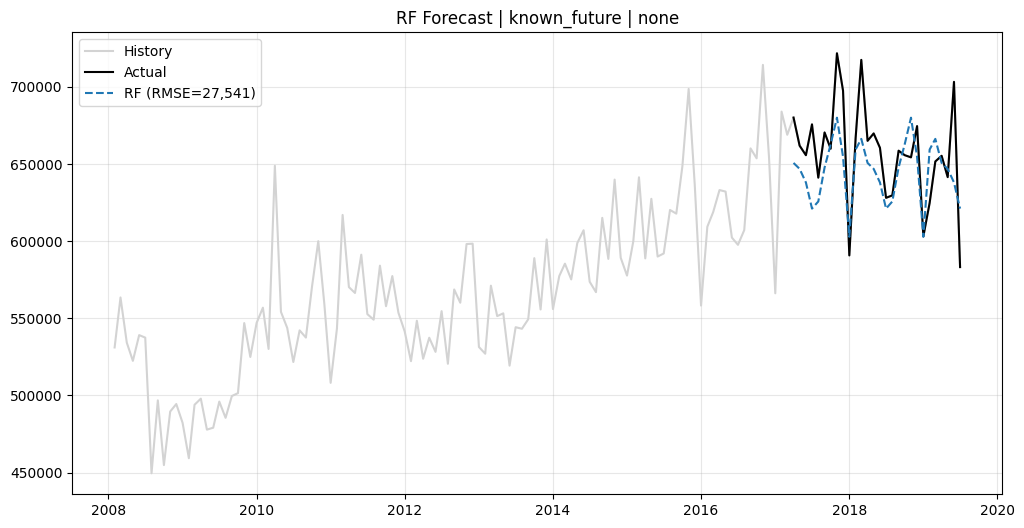


Feature Importance:
year_scaled    0.7706
month_cos      0.1172
month_sin      0.1122
dtype: float64


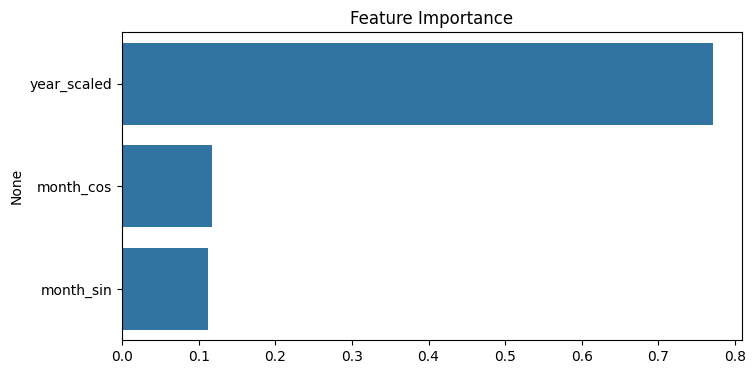

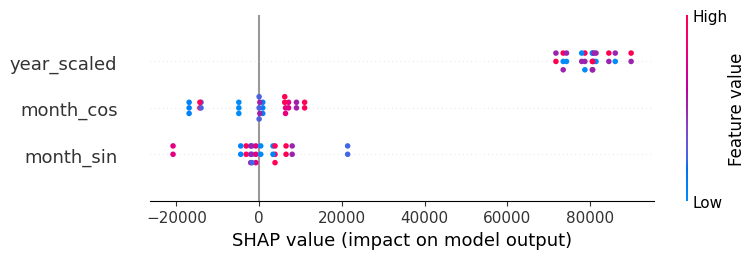


RF | Outlier: none | Features: lags
Running GridSearchCV...
Best params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
RMSE = $57,215.04


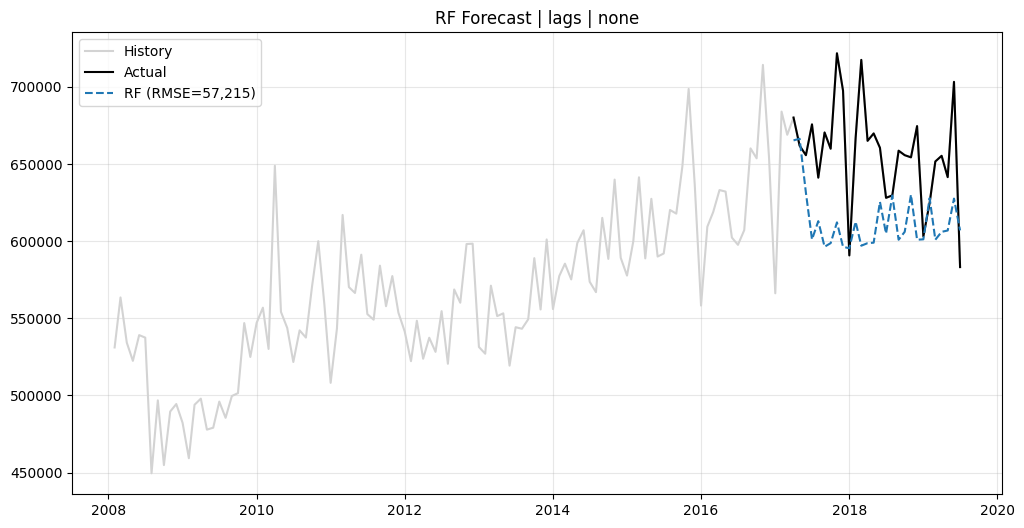


Feature Importance:
price_lag_1     0.7218
price_lag_12    0.2782
dtype: float64


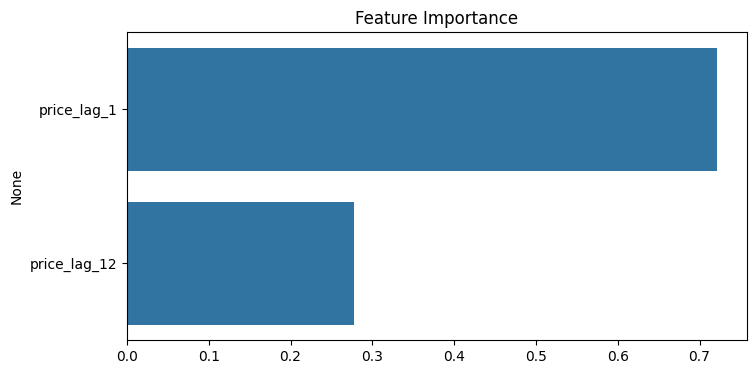

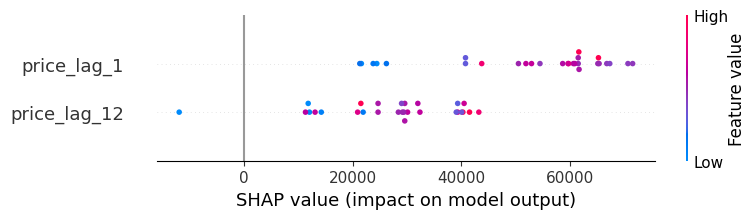


RF | Outlier: none | Features: all
Running GridSearchCV...
Best params: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 500}
RMSE = $50,979.69


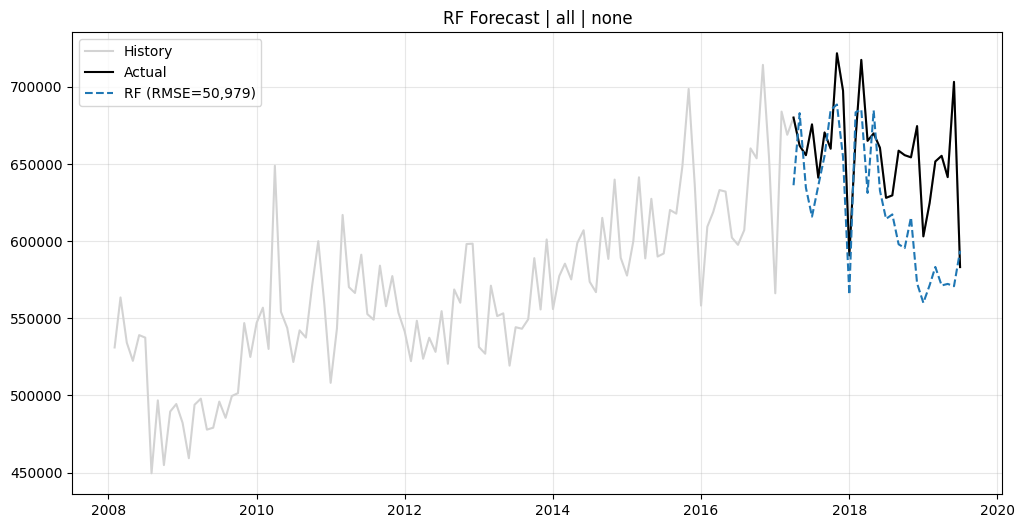


Feature Importance:
sales_count     0.5600
price_lag_1     0.1677
year_scaled     0.1463
avg_bedrooms    0.0551
house_ratio     0.0364
price_lag_12    0.0189
month_sin       0.0079
month_cos       0.0076
dtype: float64


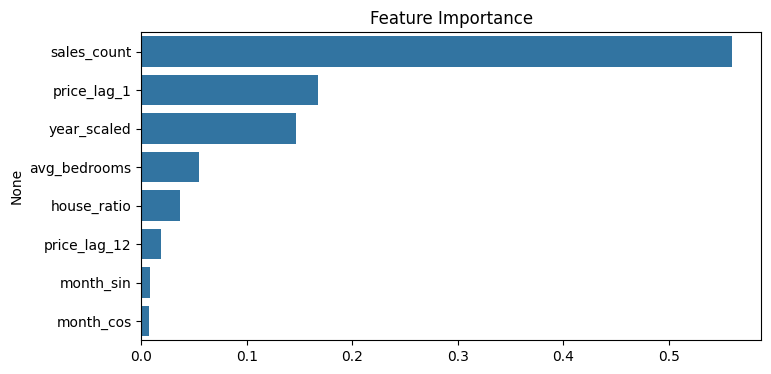

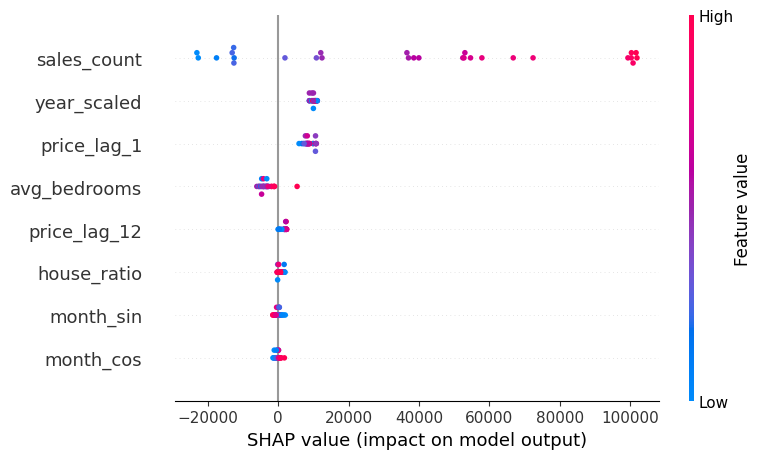


RF | Outlier: none | Features: all_and_macro
Running GridSearchCV...
Best params: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 500}
RMSE = $51,760.40


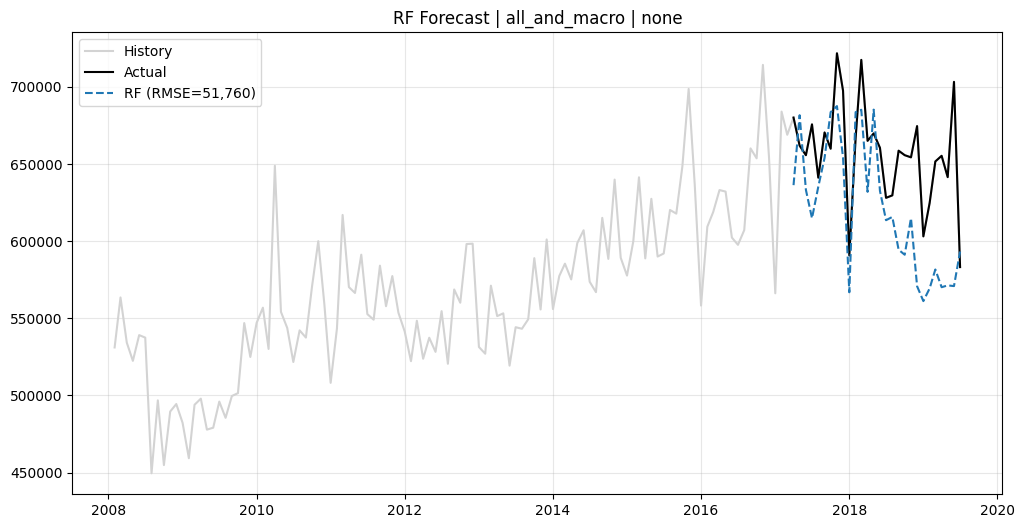


Feature Importance:
sales_count      0.5563
price_lag_1      0.1563
year_scaled      0.1120
mortgage_rate    0.0629
avg_bedrooms     0.0528
house_ratio      0.0273
price_lag_12     0.0158
month_sin        0.0068
month_cos        0.0061
median_income    0.0036
dtype: float64


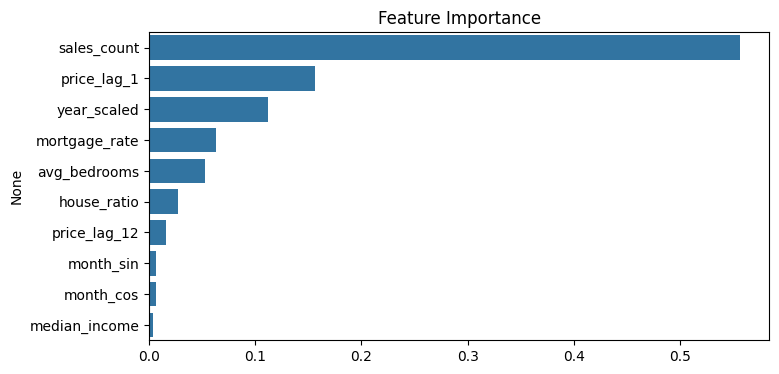

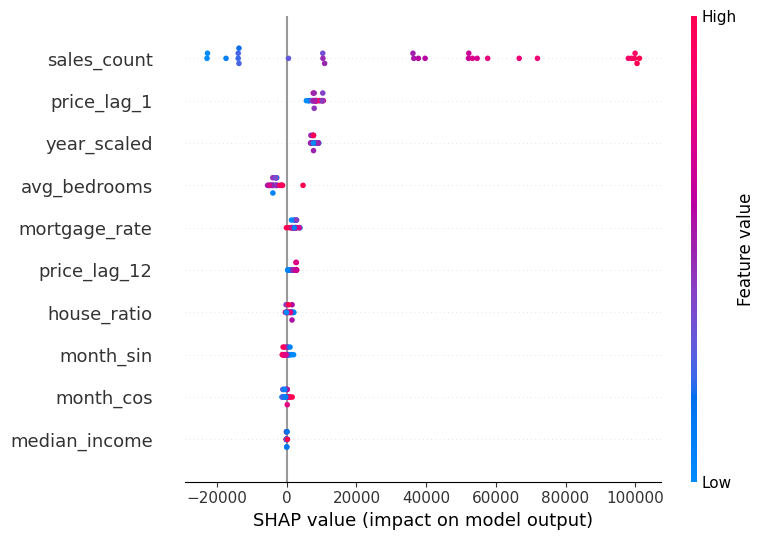

In [58]:
random_forest_evaluation_pipeline(
    df=df,
    pipeline_function=pipeline,
    add_seasonality_function=add_seasonality_features,
    feature_keys=FEATURE_SETS.keys(), # Updated feature keys
    outlier_methods=("none",),# "remove"),

    use_lags=True,
    lag_values=(1, 12),

    plot=True,
    use_shap=True,
    grid_search=True,
)

### LSTM

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [42]:
# ── Run LSTM models across outlier strategies ─────────────────────────────────
def create_sequences(X, y, seq_len=12):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i + seq_len])
        ys.append(y[i + seq_len])
    return np.array(Xs), np.array(ys)


# feats = {
#     'seasonality': ['month_sin', 'month_cos', 'year_scaled', 'avg_bedrooms', 'house_ratio', 'sales_count'],
#     'non-seasonality': ['avg_bedrooms', 'house_ratio', 'sales_count'],
# }


# ── Univariate LSTM (price only) — unchanged from original ───────────────────
def run_lstm_univariate(monthly_df_cleaned, train_size):
    seq_len = 12

    split_index = int(len(monthly_df_cleaned) * train_size)
    train_df = monthly_df_cleaned.iloc[:split_index]
    test_df  = monthly_df_cleaned.iloc[split_index:]

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_df[['price']])
    test_scaled  = scaler.transform(test_df[['price']])

    X_train, y_train = create_sequences(train_scaled, train_scaled, seq_len)

    model = Sequential([
        LSTM(64, input_shape=(seq_len, 1)),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    #this model can, in a single pass, output how many price predictions?
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=40, batch_size=16, verbose=0)

    current_seq = train_scaled[-seq_len:]
    preds_scaled = []
    for _ in range(len(test_scaled)):
        next_pred = model.predict(current_seq.reshape(1, seq_len, 1), verbose=0)[0][0]
        preds_scaled.append(next_pred)  # Each new current_seq is built from previous predictions (next_pred), not from the true future price.
        current_seq = np.append(current_seq[1:], [[next_pred]], axis=0)

    preds_scaled = np.array(preds_scaled).reshape(-1, 1)
    preds        = scaler.inverse_transform(preds_scaled)
    y_test_real  = test_df[['price']].values
    mse          = mean_squared_error(y_test_real, preds)
    return preds, y_test_real, mse


# ── Multivariate LSTM with optional seasonality features ──────────────────────
'''def run_lstm_multivariate(monthly_df_with_season, train_size, feature_cols, seq_len=12):
    """
    Multivariate LSTM using the provided feature_cols as inputs to predict
    monthly mean price.

    * Scalers are fit ONLY on the training split (no data leakage).
    * Forecasting on the test set is recursive in time: at each step we slide
      the window forward, feeding in true future exogenous values (from
      feature_cols) while the price column is updated with the model's own
      prediction (through the target scaler).
    """
    target = 'price'
    df_s = monthly_df_with_season.copy()

    # Split BEFORE scaling
    split_idx = int(len(df_s) * train_size)
    train_df  = df_s.iloc[:split_idx]
    test_df   = df_s.iloc[split_idx:]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    scaler_X.fit(train_df[feature_cols])
    scaler_y.fit(train_df[[target]])

    train_scaled = scaler_X.transform(train_df[feature_cols])
    test_scaled  = scaler_X.transform(test_df[feature_cols])
    y_train_sc   = scaler_y.transform(train_df[[target]])
    y_test_sc    = scaler_y.transform(test_df[[target]])

    X_train_seq, y_train_seq = create_sequences(train_scaled, y_train_sc, seq_len)

    model = Sequential([
        LSTM(64, return_sequences=False, input_shape=(seq_len, len(feature_cols))),  # 64 is the number of LSTM units
        Dense(32, activation='relu'),  # fully connected layer to help multivariate learning
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train_seq, y_train_seq, epochs=40, batch_size=16, verbose=0)

    # Recursive forecasting: slide window over test, using true exog features
    current_seq  = train_scaled[-seq_len:].copy()
    preds_scaled = []
    for i in range(len(test_scaled)):
        inp  = current_seq.reshape(1, seq_len, len(feature_cols))
        pred = model.predict(inp, verbose=0)[0, 0]
        preds_scaled.append(pred)
        current_seq = np.vstack([current_seq[1:], test_scaled[i]])

    preds_scaled  = np.array(preds_scaled).reshape(-1, 1)
    preds         = scaler_y.inverse_transform(preds_scaled).flatten()
    y_test_real   = scaler_y.inverse_transform(y_test_sc).flatten()
    mse           = mean_squared_error(y_test_real, preds)

    return model, scaler_X, scaler_y, train_scaled, test_scaled, y_train_sc, y_test_sc, preds, y_test_real, mse
'''


def run_lstm_univariate_seq2seq(monthly_df_cleaned, train_size, seq_len=12, horizon=12):
    """
    Sequence-to-sequence univariate LSTM:
    - input:  seq_len past prices
    - output: horizon future prices (vector), predicted in one shot
    """
    # Extract target as numpy array
    prices = monthly_df_cleaned[['price']].values

    # Train / test split on ORIGINAL scale
    split_index = int(len(prices) * train_size)
    train_vals = prices[:split_index]
    test_vals  = prices[split_index:]

    # Scale ONLY on train to avoid leakage
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_vals)
    test_scaled  = scaler.transform(test_vals)

    # Helper: build (X, y) for multi-step forecasting
    def create_multistep_sequences(series_scaled, seq_len, horizon):
        Xs, ys = [], []
        # Only use training part to build sequences
        for i in range(len(series_scaled) - seq_len - horizon + 1):
            Xs.append(series_scaled[i : i + seq_len])
            ys.append(series_scaled[i + seq_len : i + seq_len + horizon].flatten())
        return np.array(Xs), np.array(ys)

    X_train, y_train = create_multistep_sequences(train_scaled, seq_len, horizon)

    # LSTM model: outputs a vector of length = horizon
    model = Sequential([
        LSTM(64, input_shape=(seq_len, 1)),
        Dense(32, activation='relu'),
        Dense(horizon)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=40, batch_size=16, verbose=0)

    # ---- Inference on test horizon -----------------------------------------
    # Use the LAST seq_len points from the *train* set as conditioning window
    if len(test_scaled) < horizon:
        raise ValueError(f"horizon={horizon} is longer than test set ({len(test_scaled)}). "
                         f"Reduce horizon or hold out more data for testing.")

    last_train_window = train_scaled[-seq_len:]          # shape (seq_len, 1)
    last_train_window = last_train_window.reshape(1, seq_len, 1)

    preds_scaled_vec = model.predict(last_train_window, verbose=0)[0]  # shape (horizon,)
    preds_scaled_vec = preds_scaled_vec.reshape(-1, 1)

    # Inverse-transform predictions and actuals
    preds = scaler.inverse_transform(preds_scaled_vec).flatten()
    actual = scaler.inverse_transform(test_scaled[:horizon]).flatten()

    mse = mean_squared_error(actual, preds)

    # For plotting convenience, also return the corresponding test index slice
    test_index = monthly_df_cleaned.iloc[split_index : split_index + horizon].index

    return model, preds, actual, mse, test_index

In [43]:
def lstm_evaluation_pipeline_univariate(
    types_of_outlier=("none", "remove", "log_transform"),
    seasonality=True,
    plot=True,
    models=("univariate", "sequential"),
    explain=True,
    seq_len=12,
    horizon=12,
    train_size=train_size,
):
    """
    models: tuple of any of
        - 'univariate'   : 1-step recursive univariate LSTM
        - 'multivariate' : multivariate LSTM with feature_sets
        - 'sequential'   : seq2seq univariate LSTM (multi-step in one shot)
    """

    for type_of_outlier in types_of_outlier:
        # Build monthly_df for this outlier strategy
        _, _, monthly_df_cleaned = pipeline(
            df, type_of_outlier=type_of_outlier, plotting=False
        )

        print(f"\n=== LSTM | outlier method: {type_of_outlier} ===")

        # ---------- Univariate 1-step LSTM (always run to get y_test) -----------
        preds_uni, y_uni, _ = run_lstm_univariate(
            monthly_df_cleaned, train_size=train_size
        )

        # ---------- Seq2Seq univariate LSTM (optional) -------------------------
        seq_available = False
        if "sequential" in models:
            try:
                (
                    model_seq2seq,
                    preds_seq,
                    actual_seq,
                    mse_seq,
                    test_idx_seq,
                ) = run_lstm_univariate_seq2seq(
                    monthly_df_cleaned,
                    train_size=train_size,
                    seq_len=seq_len,
                    horizon=horizon,
                )

                if type_of_outlier == "log_transform":
                    actual_seq_dollar = np.exp(actual_seq)
                    preds_seq_dollar = np.exp(preds_seq)
                else:
                    actual_seq_dollar = actual_seq
                    preds_seq_dollar = preds_seq

                rmse_seq = calculate_rmse(actual_seq_dollar, preds_seq_dollar)
                seq_available = True
            except ValueError as e:
                print(f"Seq2Seq not run (horizon issue): {e}")
                rmse_seq = None

        # ---------- Feature-set loop for multivariate + plots/SHAP -------------


# ...existing code...

# Example:
lstm_evaluation_pipeline_univariate(
    types_of_outlier=("none", "remove", "log_transform"),
    seasonality=True,
    plot=False,
    models = ("univariate", "sequential"),
    explain=False,
    seq_len=12,
    horizon=12,
    train_size=train_size,
)


=== LSTM | outlier method: none ===

=== LSTM | outlier method: remove ===

=== LSTM | outlier method: log_transform ===


In [44]:
from itertools import product

def run_lstm_multivariate2(
    monthly_df,
    feature_cols_exog,
    train_size=train_size,
    seq_len=12,
    lstm_units=64,
    dense_units=32,
    epochs=40,
    batch_size=16,
):
    """
    Multivariate AUTOREGRESSIVE LSTM.

    Inputs per timestep:
        [price_lag, exogenous_features]

    IMPORTANT:
    - price history is included as input
    - future true prices are NEVER used
    - scalers fit ONLY on training data
    """

    df = monthly_df.copy()
    target = "price"

    # Include price history as feature 0
    feature_cols = ["price"] + feature_cols_exog

    # -------- Split BEFORE scaling ----------
    split_idx = int(len(df) * train_size)
    train_df = df.iloc[:split_idx]
    test_df  = df.iloc[split_idx:]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    scaler_X.fit(train_df[feature_cols])
    scaler_y.fit(train_df[[target]])

    train_X = scaler_X.transform(train_df[feature_cols])
    test_X  = scaler_X.transform(test_df[feature_cols])

    train_y = scaler_y.transform(train_df[[target]])
    test_y  = scaler_y.transform(test_df[[target]])

    # -------- Build sequences ----------
    def create_sequences(X, y, seq_len):
        Xs, ys = [], []
        for i in range(len(X) - seq_len):
            Xs.append(X[i:i+seq_len])
            ys.append(y[i+seq_len])
        return np.array(Xs), np.array(ys)

    X_train_seq, y_train_seq = create_sequences(train_X, train_y, seq_len)

    # -------- Build model ----------
    model = Sequential([
        LSTM(lstm_units, input_shape=(seq_len, len(feature_cols))),
        Dense(dense_units, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")

    model.fit(X_train_seq, y_train_seq,
              epochs=epochs,
              batch_size=batch_size,
              verbose=0)

    # -------- Recursive forecasting ----------
    current_seq = train_X[-seq_len:].copy()
    preds_scaled = []

    for i in range(len(test_df)):
        pred = model.predict(
            current_seq.reshape(1, seq_len, len(feature_cols)),
            verbose=0
        )[0,0]

        preds_scaled.append(pred)

        next_row = test_X[i].copy()
        next_row[0] = pred   # replace unknown future price
        current_seq = np.vstack([current_seq[1:], next_row])

    preds = scaler_y.inverse_transform(
        np.array(preds_scaled).reshape(-1,1)
    ).flatten()

    actual = scaler_y.inverse_transform(test_y).flatten()
    rmse = np.sqrt(mean_squared_error(actual, preds))

    return model, preds, actual, rmse

def gridsearch_lstm(
    monthly_df,
    feature_cols,
    param_grid,
    seq_len,
    train_size,
):
    best = None
    results = []

    for params in product(*param_grid.values()):
        cfg = dict(zip(param_grid.keys(), params))

        _, _, _, rmse = run_lstm_multivariate2(
            monthly_df,
            feature_cols_exog=feature_cols,
            train_size=train_size,
            seq_len=seq_len,
            **cfg,
        )

        results.append((cfg, rmse))
        print(cfg, "RMSE:", rmse)

        if best is None or rmse < best[1]:
            best = (cfg, rmse)

    print("\nBest:", best)
    return best, results

param_grid = {
    "lstm_units": [32, 64],
    "dense_units": [16, 32],
    "epochs": [30, 50],
}

In [45]:
def lstm_evaluation_pipeline2(
    df,
    feature_sets,
    types_of_outlier=("none", "remove", "log_transform"),
    train_size=train_size,
    seq_len=12,
    gridsearch=False,
    param_grid=None,
    plot=True,
    explain=True,
):
    """
    Multivariate autoregressive LSTM evaluation pipeline.

    Parameters
    ----------
    feature_sets : dict
        Example:
            {
              "known": [...],
              "all": [...],
            }

    gridsearch : bool
        Whether to perform hyperparameter search.

    plot : bool
        Plot predictions vs actuals.

    explain : bool
        Run SHAP explanation.
    """

    for type_of_outlier in types_of_outlier:

        # ---------------------------------------------------------
        # Build dataset for this outlier strategy
        # ---------------------------------------------------------
        _, _, monthly_df_cleaned = pipeline(
            df,
            type_of_outlier=type_of_outlier,
            plotting=False
        )

        monthly_df_cleaned = add_seasonality_features(monthly_df_cleaned)

        print(f"\n=== LSTM | outlier method: {type_of_outlier} ===")

        for feat_name, feature_cols_exog in feature_sets.items():

            print(
                f"\n--- LSTM | outlier: {type_of_outlier} "
                f"| features: {feat_name} ---"
            )

            # -----------------------------------------------------
            # Optional Grid Search
            # -----------------------------------------------------
            best_params = {}
            if gridsearch and param_grid is not None:
                best, _ = gridsearch_lstm(
                    monthly_df_cleaned,
                    feature_cols=feature_cols_exog,
                    param_grid=param_grid,
                    seq_len=seq_len,
                    train_size=train_size,
                )
                best_params = best[0]
                print("Best params:", best_params)

            # -----------------------------------------------------
            # Train Model
            # -----------------------------------------------------
            model, preds, actual, rmse = run_lstm_multivariate2(
                monthly_df_cleaned,
                feature_cols_exog=feature_cols_exog,
                train_size=train_size,
                seq_len=seq_len,
                **best_params
            )

            if type_of_outlier == "log_transform":
                actual_dollar = np.exp(actual)
                preds_dollar = np.exp(preds)
                rmse_dollar = calculate_rmse(actual_dollar, preds_dollar)
                history_dollar = np.exp(monthly_df_cleaned["price"].values)
                print(f"Multivariate LSTM RMSE ({feat_name}): ${rmse_dollar:,.2f}")

            else:
                history_dollar = monthly_df_cleaned["price"].values
                actual_dollar = actual
                preds_dollar = preds
                print(f"Multivariate LSTM RMSE ({feat_name}): ${rmse:,.2f}")

            split_idx = int(len(monthly_df_cleaned) * train_size)
            test_dates = monthly_df_cleaned.iloc[split_idx:].index
            full_dates = monthly_df_cleaned.index

            # =====================================================
            # ===================== PLOTTING ======================
            # =====================================================
            if plot:

                plt.figure(figsize=(12, 6))

                plt.plot(
                    full_dates,
                    history_dollar,
                    label="Actual History",
                    color="lightgray",
                    linewidth=2,
                )

                plt.plot(
                    test_dates,
                    actual_dollar,
                    label="Actual Test",
                    color="black",
                    linewidth=2,
                )

                plt.plot(
                    test_dates,
                    preds_dollar,
                    label=f"LSTM ({feat_name}) (RMSE=${int(rmse):,})",
                    linestyle="--",
                    linewidth=2,
                )

                plt.title(
                    f"LSTM Predictions vs Actuals "
                    f"(method: {type_of_outlier}, features: {feat_name})"
                )
                plt.xlabel("Date")
                plt.ylabel("Price ($)")
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.savefig(f'./imgs/lstm_forecast_{type_of_outlier}_{feat_name}.png', dpi=150, bbox_inches='tight')
                plt.show()

            # =====================================================
            # ======================= SHAP ========================
            # =====================================================
            if explain:

                print("Computing SHAP values...")

                # Rebuild scaled sequences (no leakage)
                target = "price"
                feature_cols_full = ["price"] + feature_cols_exog

                split_idx = int(len(monthly_df_cleaned) * train_size)
                train_df = monthly_df_cleaned.iloc[:split_idx]
                test_df = monthly_df_cleaned.iloc[split_idx:]

                scaler_X = MinMaxScaler()
                scaler_y = MinMaxScaler()

                scaler_X.fit(train_df[feature_cols_full])
                scaler_y.fit(train_df[[target]])

                train_X = scaler_X.transform(train_df[feature_cols_full])
                test_X = scaler_X.transform(test_df[feature_cols_full])
                train_y = scaler_y.transform(train_df[[target]])

                def create_sequences(X, y, seq_len):
                    Xs, ys = [], []
                    for i in range(len(X) - seq_len):
                        Xs.append(X[i:i+seq_len])
                        ys.append(y[i+seq_len])
                    return np.array(Xs), np.array(ys)

                X_train_seq, y_train_seq = create_sequences(
                    train_X, train_y, seq_len
                )

                X_all_seq, _ = create_sequences(
                    np.vstack([train_X, test_X]),
                    scaler_y.transform(monthly_df_cleaned[[target]]),
                    seq_len
                )

                X_test_seq = X_all_seq[split_idx - seq_len:]

                # Background for SHAP
                bg_idx = np.random.choice(
                    len(X_train_seq),
                    size=min(100, len(X_train_seq)),
                    replace=False,
                )
                background = X_train_seq[bg_idx]

                explainer = shap.GradientExplainer(model, background)
                shap_raw = explainer.shap_values(X_test_seq)

                if isinstance(shap_raw, list):
                    shap_raw = shap_raw[0]

                shap_raw = np.array(shap_raw)

                if shap_raw.ndim > 3:
                    shap_raw = np.squeeze(shap_raw)

                if shap_raw.ndim == 3:
                    shap_abs = np.abs(shap_raw).mean(axis=1)
                else:
                    shap_abs = np.abs(shap_raw)

                mean_shap = shap_abs.mean(axis=0)
                feature_names = np.array(feature_cols_full)

                sorted_idx = np.argsort(mean_shap)[::-1]

                # ---------- Bar plot ----------
                plt.figure(figsize=(8, 4))
                sns.barplot(
                    x=mean_shap[sorted_idx],
                    y=feature_names[sorted_idx],
                    palette="magma",
                )
                plt.title(
                    f"LSTM – Mean |SHAP value| "
                    f"(method: {type_of_outlier}, features: {feat_name})"
                )
                plt.xlabel("Mean |SHAP value|")
                plt.tight_layout()
                plt.savefig(f'./imgs/lstm_shap_bar_{type_of_outlier}_{feat_name}.png', dpi=150, bbox_inches='tight')
                plt.show()

                # ---------- Summary plot (last timestep) ----------
                if shap_raw.ndim == 3:
                    shap_last = shap_raw[:, -1, :]
                    X_last = X_test_seq[:, -1, :]

                    shap.summary_plot(
                        shap_last,
                        X_last,
                        feature_names=feature_names.tolist(),
                        show=False,
                    )

                    plt.title(
                        f"SHAP summary (last time step)\n"
                        f"(method: {type_of_outlier}, features: {feat_name})"
                    )
                    plt.tight_layout()
                    plt.savefig(f'./imgs/lstm_shap_summary_{type_of_outlier}_{feat_name}.png', dpi=150, bbox_inches='tight')
                    plt.show()

In [46]:
FEATURE_SETS = {
    # Safe long-term forecasting (only calendar, no market variables)
    "known_future": [
        "month_sin",
        "month_cos",
        "year_scaled",
    ],

    # Market features that may be unknown in the future
    "all": [
        "month_sin",
        "month_cos",
        "year_scaled",
        "avg_bedrooms",
        "house_ratio",
        "sales_count",
    ],

    # Everything
    "all_and_macro": [
        "month_sin",
        "month_cos",
        "year_scaled",
        "avg_bedrooms",
        "house_ratio",
        "sales_count",
        "mortgage_rate",
        "median_income",
    ],
}


=== LSTM | outlier method: none ===

--- LSTM | outlier: none | features: known_future ---
{'lstm_units': 32, 'dense_units': 16, 'epochs': 30} RMSE: 41561.5046173657
{'lstm_units': 32, 'dense_units': 16, 'epochs': 50} RMSE: 41292.02419106142
{'lstm_units': 32, 'dense_units': 32, 'epochs': 30} RMSE: 42304.60505708183
{'lstm_units': 32, 'dense_units': 32, 'epochs': 50} RMSE: 51167.811828585945
{'lstm_units': 64, 'dense_units': 16, 'epochs': 30} RMSE: 40136.444557567775
{'lstm_units': 64, 'dense_units': 16, 'epochs': 50} RMSE: 37585.4831998224
{'lstm_units': 64, 'dense_units': 32, 'epochs': 30} RMSE: 39638.41782100197
{'lstm_units': 64, 'dense_units': 32, 'epochs': 50} RMSE: 39100.32813498839

Best: ({'lstm_units': 64, 'dense_units': 16, 'epochs': 50}, np.float64(37585.4831998224))
Best params: {'lstm_units': 64, 'dense_units': 16, 'epochs': 50}
Multivariate LSTM RMSE (known_future): $39,435.93


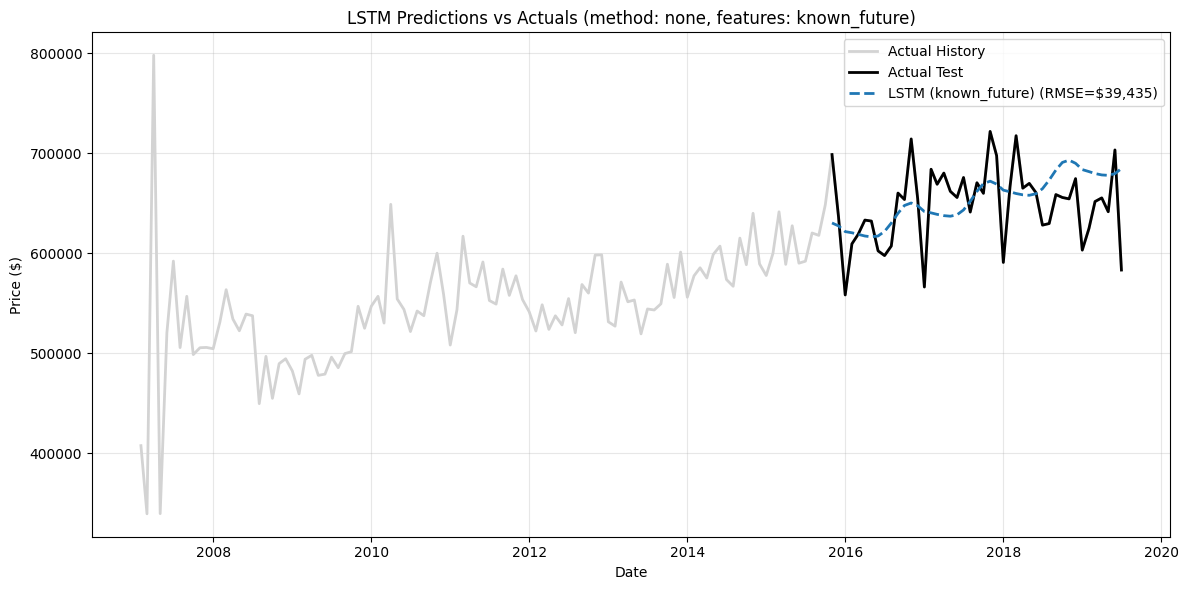

Computing SHAP values...


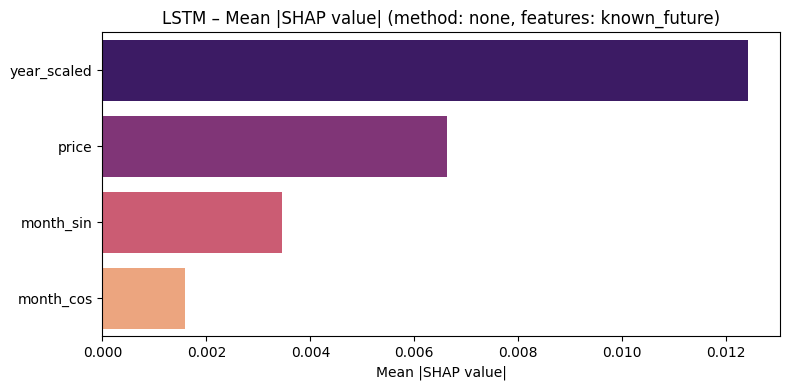

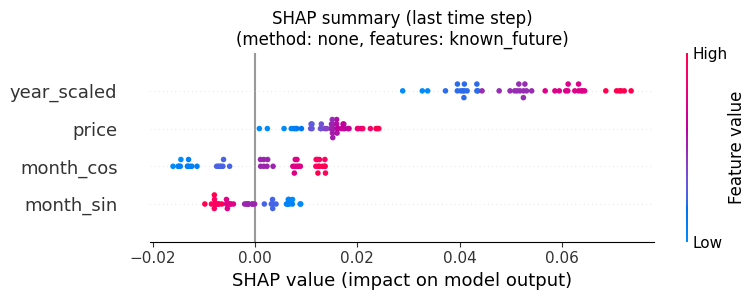


--- LSTM | outlier: none | features: all ---
{'lstm_units': 32, 'dense_units': 16, 'epochs': 30} RMSE: 46363.32904434484
{'lstm_units': 32, 'dense_units': 16, 'epochs': 50} RMSE: 74860.98386843667
{'lstm_units': 32, 'dense_units': 32, 'epochs': 30} RMSE: 36510.06335258241
{'lstm_units': 32, 'dense_units': 32, 'epochs': 50} RMSE: 55171.066213121936
{'lstm_units': 64, 'dense_units': 16, 'epochs': 30} RMSE: 47339.60961343817
{'lstm_units': 64, 'dense_units': 16, 'epochs': 50} RMSE: 46546.941793247985
{'lstm_units': 64, 'dense_units': 32, 'epochs': 30} RMSE: 37398.24800360877
{'lstm_units': 64, 'dense_units': 32, 'epochs': 50} RMSE: 37788.01764892173

Best: ({'lstm_units': 32, 'dense_units': 32, 'epochs': 30}, np.float64(36510.06335258241))
Best params: {'lstm_units': 32, 'dense_units': 32, 'epochs': 30}
Multivariate LSTM RMSE (all): $44,631.19


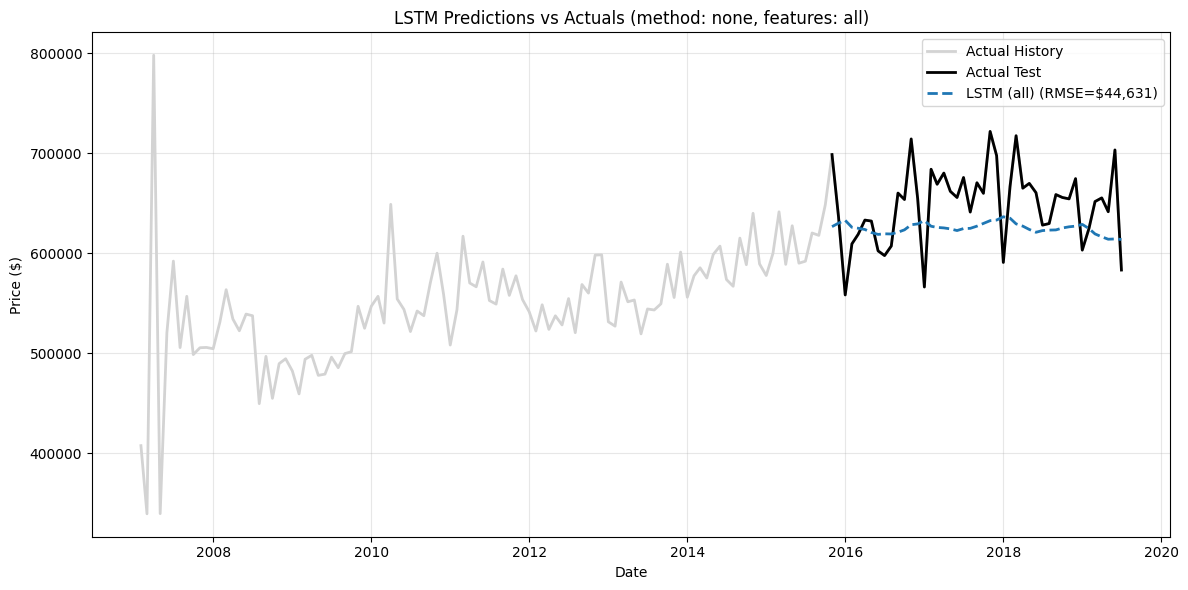

Computing SHAP values...


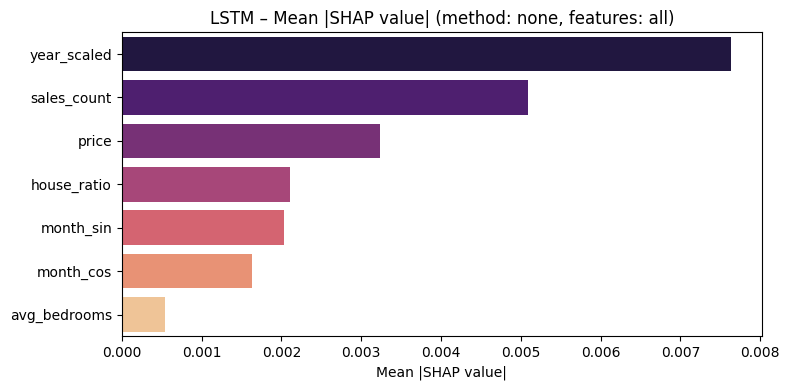

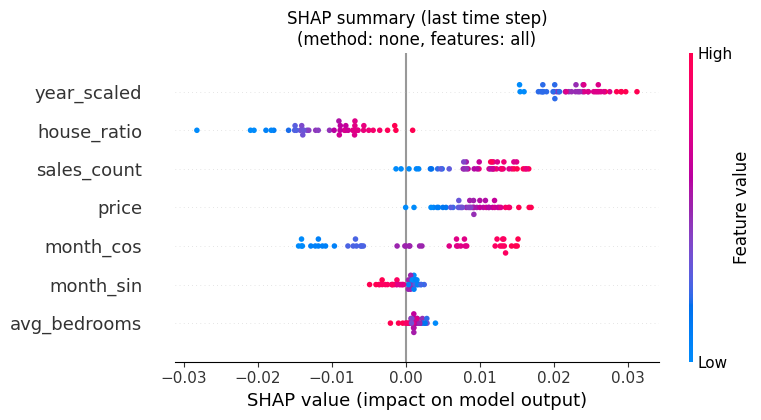


--- LSTM | outlier: none | features: all_and_macro ---
{'lstm_units': 32, 'dense_units': 16, 'epochs': 30} RMSE: 45831.64383960271
{'lstm_units': 32, 'dense_units': 16, 'epochs': 50} RMSE: 77566.68685461272
{'lstm_units': 32, 'dense_units': 32, 'epochs': 30} RMSE: 57189.08055994734
{'lstm_units': 32, 'dense_units': 32, 'epochs': 50} RMSE: 42779.14426006593
{'lstm_units': 64, 'dense_units': 16, 'epochs': 30} RMSE: 41005.570912006435
{'lstm_units': 64, 'dense_units': 16, 'epochs': 50} RMSE: 67140.54074813053
{'lstm_units': 64, 'dense_units': 32, 'epochs': 30} RMSE: 45464.25128569953
{'lstm_units': 64, 'dense_units': 32, 'epochs': 50} RMSE: 40309.81630727127

Best: ({'lstm_units': 64, 'dense_units': 32, 'epochs': 50}, np.float64(40309.81630727127))
Best params: {'lstm_units': 64, 'dense_units': 32, 'epochs': 50}
Multivariate LSTM RMSE (all_and_macro): $42,711.42


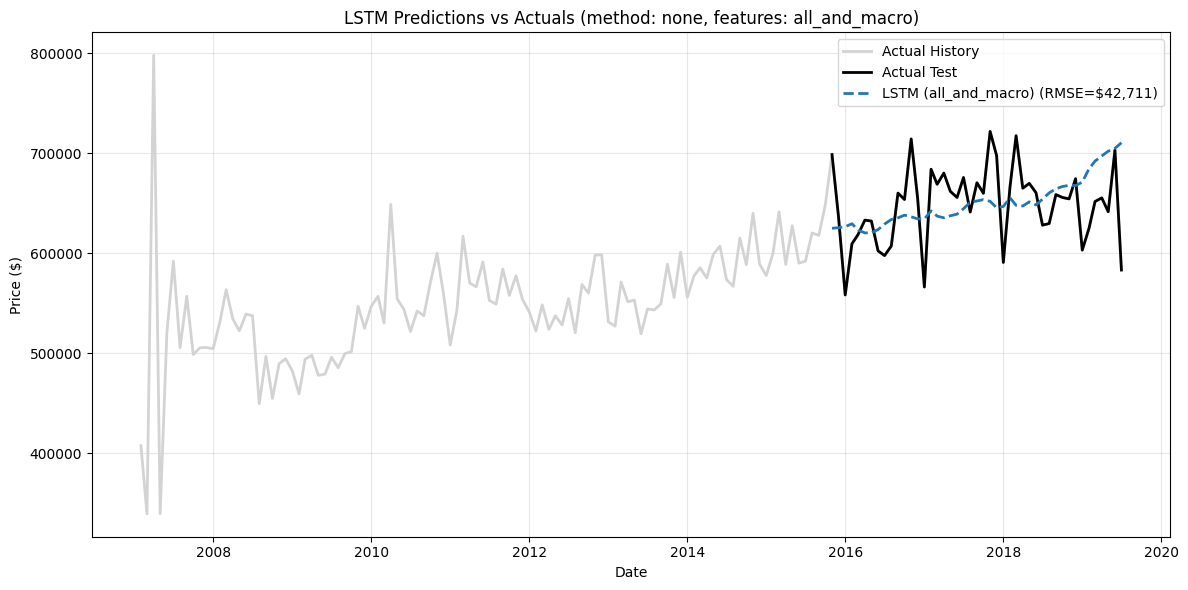

Computing SHAP values...


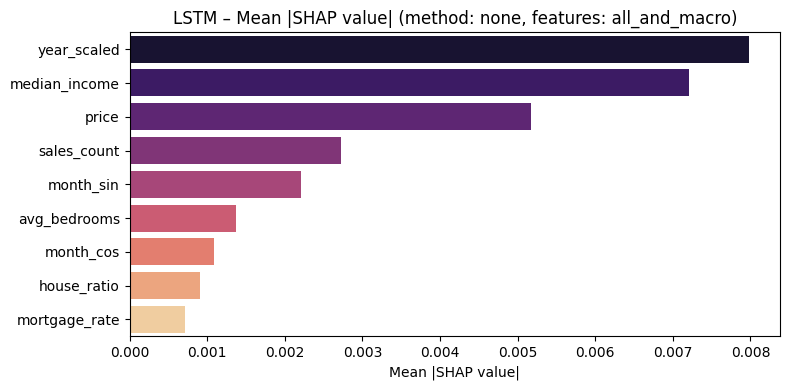

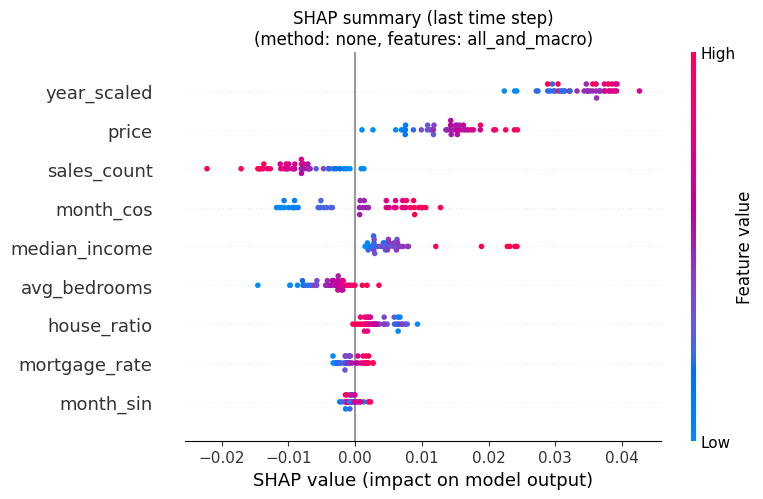

In [47]:
lstm_evaluation_pipeline2(
    df,
    feature_sets=FEATURE_SETS,
    types_of_outlier=("none",),  # make this a single-element tuple
    train_size=train_size,
    param_grid=param_grid,
    seq_len=12,
    gridsearch=True,
    plot=True,
    explain=True,
)

### SARIMAX

**SARIMAX + deterministic seasonality**

SARIMAX already captures stochastic seasonal autocorrelation via its seasonal AR/MA terms `(P,D,Q)[m=12]`.  
Adding `month_sin`, `month_cos` as exogenous regressors on top introduces *deterministic* seasonality — a fixed, repeatable within-year shape — which is complementary rather than redundant.  
`year_scaled` captures the long-run price trend as a smooth exogenous slope.

We also fix two issues from the original notebook:
1. **`RMSE: $inf`** — caused by numerical instability in the covariance matrix. Fixed by using `method='lbfgs'` and `cov_type='robust'`.
2. **Order selection** — `auto_arima` is re-run on the expanded exogenous set so the optimal order reflects the new features.

In [48]:
%pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 44.5 MB/s eta 0:00:00


In [49]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

In [50]:
df.head()

,date,postcode,price,type,bedrooms,type_encoded,is_premium_zone,zone_type,year
0,2007-02-07,2607,525000,house,4,0,1,Premium,2007
1,2007-02-27,2906,290000,house,3,0,0,Budget,2007
2,2007-03-07,2905,328000,house,3,0,0,Budget,2007
3,2007-03-09,2905,380000,house,4,0,0,Budget,2007
4,2007-03-21,2906,310000,house,3,0,0,Budget,2007


In [51]:
def run_sarimax_experiments(
    outlier_modes=("none", "remove", "log_transform"),
    plot=True,
    explain=True,
    feature_sets=FEATURE_SETS,
    train_frac=train_size,
):

    results = {}

    for outlier_mode in outlier_modes:
        print(f"\n=== SARIMAX | outlier method: {outlier_mode} ===")

        df_cleaned, monthly, monthly_df_cleaned = pipeline(
            df, type_of_outlier=outlier_mode, plotting=False
        )
        df_monthly = add_seasonality_features(monthly_df_cleaned).asfreq("MS").dropna()

        split_idx = int(len(df_monthly) * train_frac)
        train = df_monthly.iloc[:split_idx]
        test = df_monthly.iloc[split_idx:]

        y_train = train["price"]
        y_test = test["price"]

        for feat_name, exog_cols in feature_sets.items():
            print(f"\n--- SARIMAX | outlier: {outlier_mode} | features: {feat_name} ---")

            X_train = train[exog_cols]
            X_test = test[exog_cols]

            print(f"Train: {len(train)} | Test: {len(test)}")

            auto_model = auto_arima(
                y=y_train,
                exogenous=X_train,
                seasonal=True,
                m=19,
                trace=False,
                error_action="ignore",
                suppress_warnings=True,
                stepwise=True,
                max_p=3,
                max_q=3,
                max_P=2,
                max_Q=2,
                information_criterion="aic",
            )
            print(
                f"Best ARIMA order: {auto_model.order}  |  Seasonal: {auto_model.seasonal_order}"
            )

            sarimax_model = SARIMAX(
                endog=y_train,
                exog=X_train,
                order=auto_model.order,
                seasonal_order=auto_model.seasonal_order,
                trend="n",
                enforce_stationarity=True,
                enforce_invertibility=True,
            )
            sarimax_fit = sarimax_model.fit(disp=False, method="lbfgs", cov_type="robust")
            print(sarimax_fit.summary())

            forecast = sarimax_fit.predict(
                start=test.index[0], end=test.index[-1], exog=X_test
            )

            if outlier_mode == "log_transform":
                actual_plot = np.exp(y_test)
                forecast_plot = np.exp(forecast)
                train_plot = np.exp(y_train)
            else:
                actual_plot = y_test
                forecast_plot = forecast
                train_plot = y_train

            rmse_sarimax = calculate_rmse(actual_plot.values, forecast_plot.values)
            print(f"SARIMAX RMSE ({feat_name}): ${rmse_sarimax:,.2f}")

            if outlier_mode not in results:
                results[outlier_mode] = {}
            results[outlier_mode][feat_name] = {
                "model": sarimax_fit,
                "rmse": rmse_sarimax,
                "forecast": forecast_plot,
                "actual": actual_plot,
                "train": train_plot,
                "auto_model": auto_model,
            }

            if plot:
                plt.figure(figsize=(12, 6))
                plt.plot(train.index, train_plot, color="lightblue", label="Train")
                plt.plot(test.index, actual_plot, color="black", label="Actual")
                plt.plot(
                    test.index,
                    forecast_plot,
                    color="tomato",
                    label=f"SARIMAX Forecast (RMSE=${int(rmse_sarimax):,})",
                    linewidth=2,
                )
                plt.title(f"SARIMAX Forecast vs Actual (method: {outlier_mode}, features: {feat_name})")
                plt.xlabel("Date")
                plt.ylabel("Price ($)")
                plt.legend()
                plt.grid(True, linestyle="--", alpha=0.4)
                plt.tight_layout()
                plt.savefig(f'./imgs/sarimax_forecast_{outlier_mode}_{feat_name}.png', dpi=150, bbox_inches='tight')
                plt.show()

            if explain:
                try:
                    coef = sarimax_fit.params[exog_cols]
                    ci = sarimax_fit.conf_int().loc[exog_cols]
                    colors = ["tomato" if v > 0 else "steelblue" for v in coef.values]

                    plt.figure(figsize=(8, 4))
                    plt.barh(
                        coef.index,
                        coef.values,
                        xerr=[
                            (coef - ci.iloc[:, 0]).values,
                            (ci.iloc[:, 1] - coef).values,
                        ],
                        color=colors,
                        capsize=4,
                    )
                    plt.axvline(0, color="black", linewidth=0.8)
                    plt.title(
                        f"SARIMAX Exogenous Coefficients (method: {outlier_mode}, features: {feat_name})"
                    )
                    plt.xlabel("Coefficient value")
                    plt.tight_layout()
                    plt.savefig(f'./imgs/sarimax_coefficients_{outlier_mode}_{feat_name}.png', dpi=150, bbox_inches='tight')
                    plt.show()
                except Exception as e:
                    print(f"Could not plot coefficients: {e}")

    return results


=== SARIMAX | outlier method: none ===

--- SARIMAX | outlier: none | features: all ---
Train: 105 | Test: 45
Best ARIMA order: (1, 1, 0)  |  Seasonal: (0, 0, 0, 19)
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  105
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -1276.889
Date:                Fri, 06 Mar 2026   AIC                           2563.777
Time:                        21:32:53   BIC                           2576.999
Sample:                    02-01-2007   HQIC                          2569.134
                         - 10-01-2015                                         
Covariance Type:               robust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
avg_bedrooms  3.432e+05   8.75e+04     

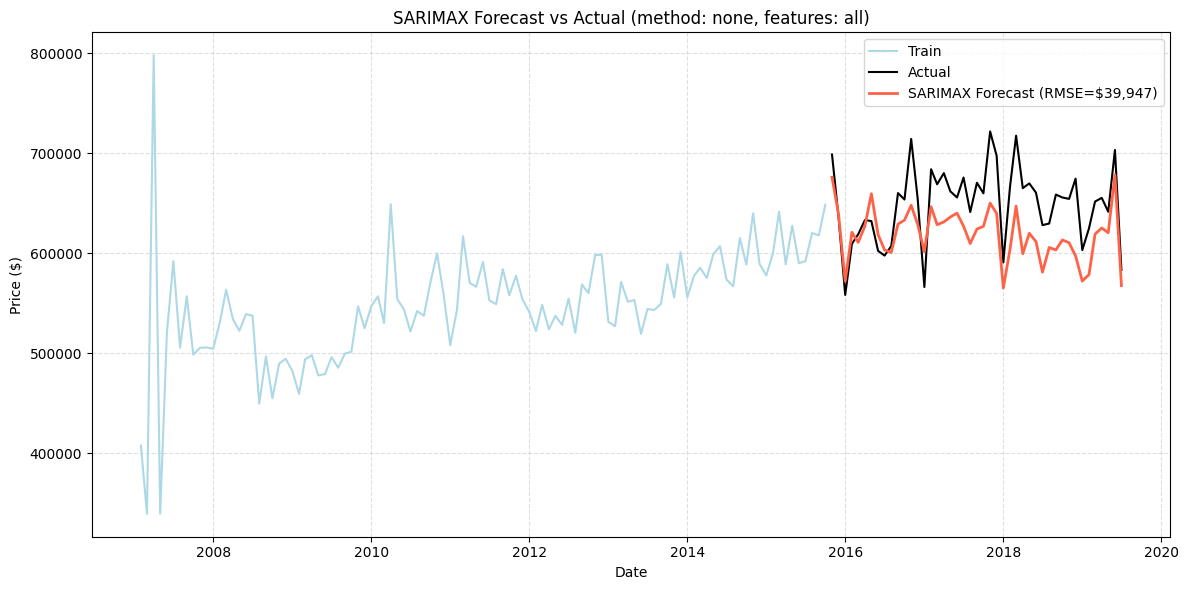

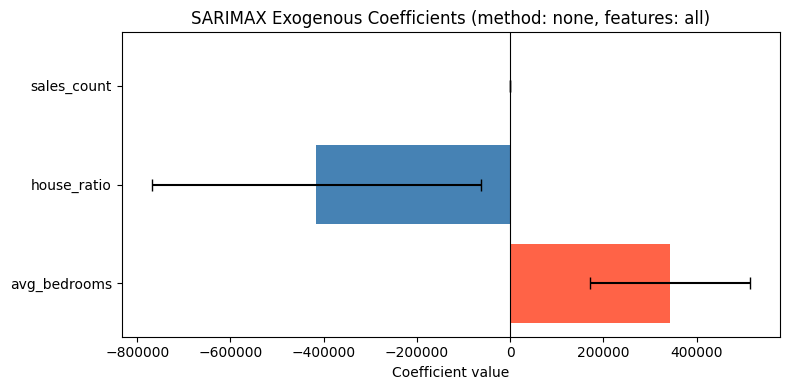


--- SARIMAX | outlier: none | features: all_and_macro ---
Train: 105 | Test: 45
Best ARIMA order: (1, 1, 0)  |  Seasonal: (0, 0, 0, 19)
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  105
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -1269.820
Date:                Fri, 06 Mar 2026   AIC                           2553.640
Time:                        21:33:08   BIC                           2572.150
Sample:                    02-01-2007   HQIC                          2561.139
                         - 10-01-2015                                         
Covariance Type:               robust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
avg_bedrooms   3.466e+05   8.74e+04      3.968      0.000    1.75e+

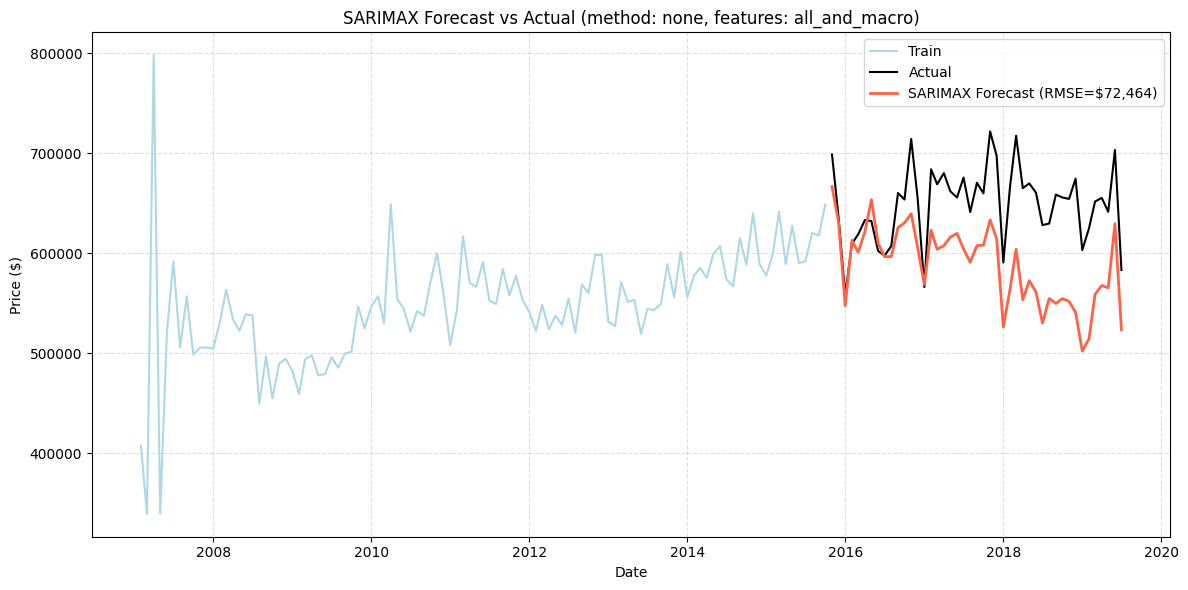

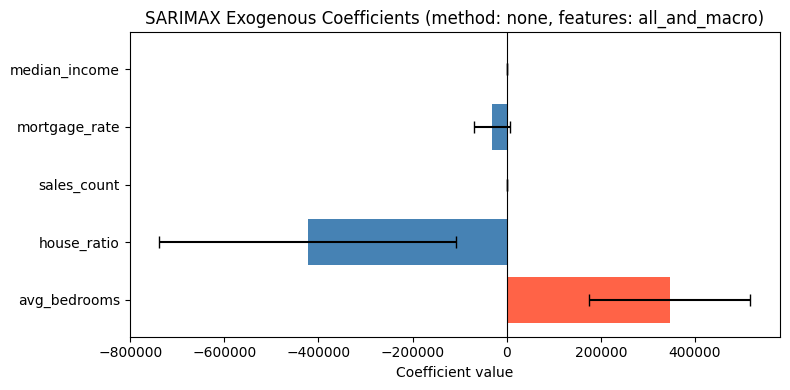


--- SARIMAX | outlier: none | features: macro ---
Train: 105 | Test: 45
Best ARIMA order: (1, 1, 0)  |  Seasonal: (0, 0, 0, 19)
                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  105
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -1285.974
Date:                Fri, 06 Mar 2026   AIC                           2581.948
Time:                        21:33:22   BIC                           2595.170
Sample:                    02-01-2007   HQIC                          2587.305
                         - 10-01-2015                                         
Covariance Type:               robust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
mortgage_rate -5065.2063   1.99e+04     -0.255      0.799   -4.41e+04    3.

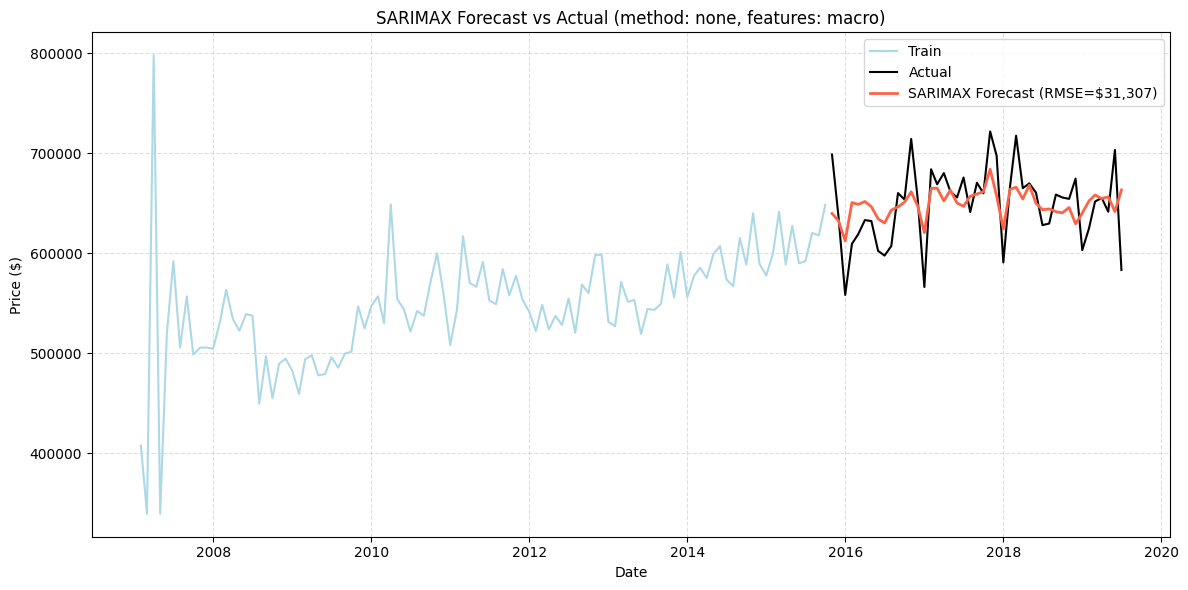

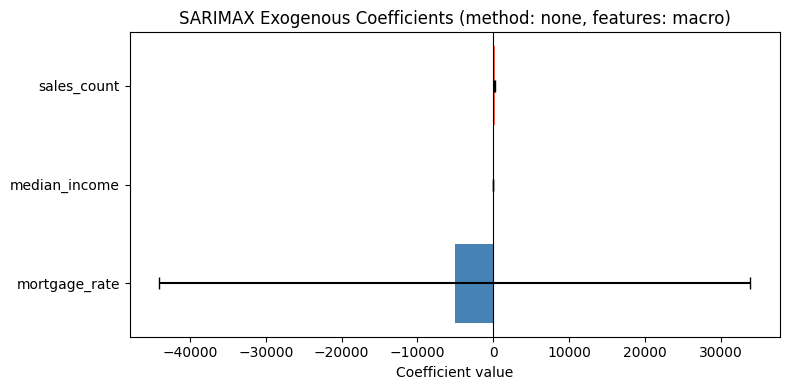

In [52]:
FEATURE_SETS = {
    # Market features that may be unknown in the future
    "all": [
        #"month_sin",
        #"month_cos",
        #"year_scaled",
        "avg_bedrooms",
        "house_ratio",
        "sales_count",
    ],

    "all_and_macro": [
        #"month_sin", already part of the seasonality part of SARIMAX
        #"month_cos",
        #"year_scaled",
        "avg_bedrooms",
        "house_ratio",
        "sales_count",
        "mortgage_rate",
        "median_income",
    ],

    "macro": [
        "mortgage_rate",
        "median_income",
        "sales_count",
        #"avg_bedrooms"
    ]
}

sarimax_results = run_sarimax_experiments(
    outlier_modes=("none",),
    plot=True,
    explain=True,
    train_frac=train_size,
    feature_sets = FEATURE_SETS,

)

In [53]:
monthly_df.head()

,price,house_ratio,avg_bedrooms,sales_count,mortgage_rate,median_income,month_sin,month_cos,year_scaled
month,,,,,,,,,
2007-02-01,407500.000000,1.000000,3.500000,2,6.006667,73010.0,8.660254e-01,5.000000e-01,-1.613876
2007-03-01,339333.333333,1.000000,3.333333,3,5.884000,73010.0,1.000000e+00,6.123234e-17,-1.613876
2007-04-01,432000.000000,1.000000,3.500000,2,5.882500,73010.0,8.660254e-01,-5.000000e-01,-1.613876
2007-05-01,339500.000000,1.000000,3.000000,2,5.968000,73010.0,5.000000e-01,-8.660254e-01,-1.613876
2007-06-01,520333.333333,0.833333,3.333333,6,6.340000,73010.0,1.224647e-16,-1.000000e+00,-1.613876


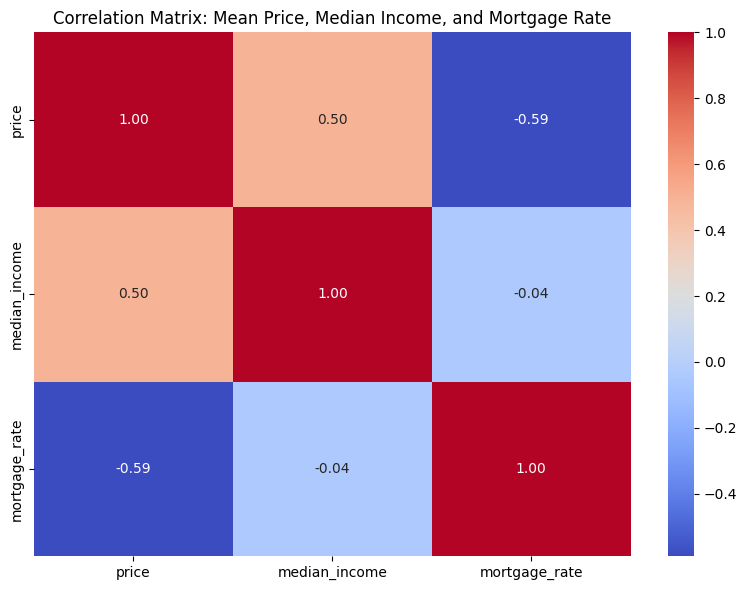

In [54]:
correlation_data = monthly_df[['price', 'median_income', 'mortgage_rate']]
correlation_matrix = correlation_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Mean Price, Median Income, and Mortgage Rate')
plt.tight_layout()
plt.savefig('./imgs/macro_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

- Mean Price and Median Income (0.58): There is a moderate positive correlation between mean price and median income. This suggests that as the median income in an area increases, property prices tend to rise, which is an expected relationship in real estate markets.
- Mean Price and Mortgage Rate (-0.54): We observe a moderate negative correlation between mean price and mortgage rates. This indicates that as mortgage rates increase, property prices tend to decrease, and vice-versa. Higher mortgage rates make borrowing more expensive, which can reduce housing affordability and dampen demand.
- Median Income and Mortgage Rate (-0.04): There is a very weak, almost negligible, negative correlation between median income and mortgage rates. This implies that these two macroeconomic factors do not have a strong linear relationship with each other in this dataset.

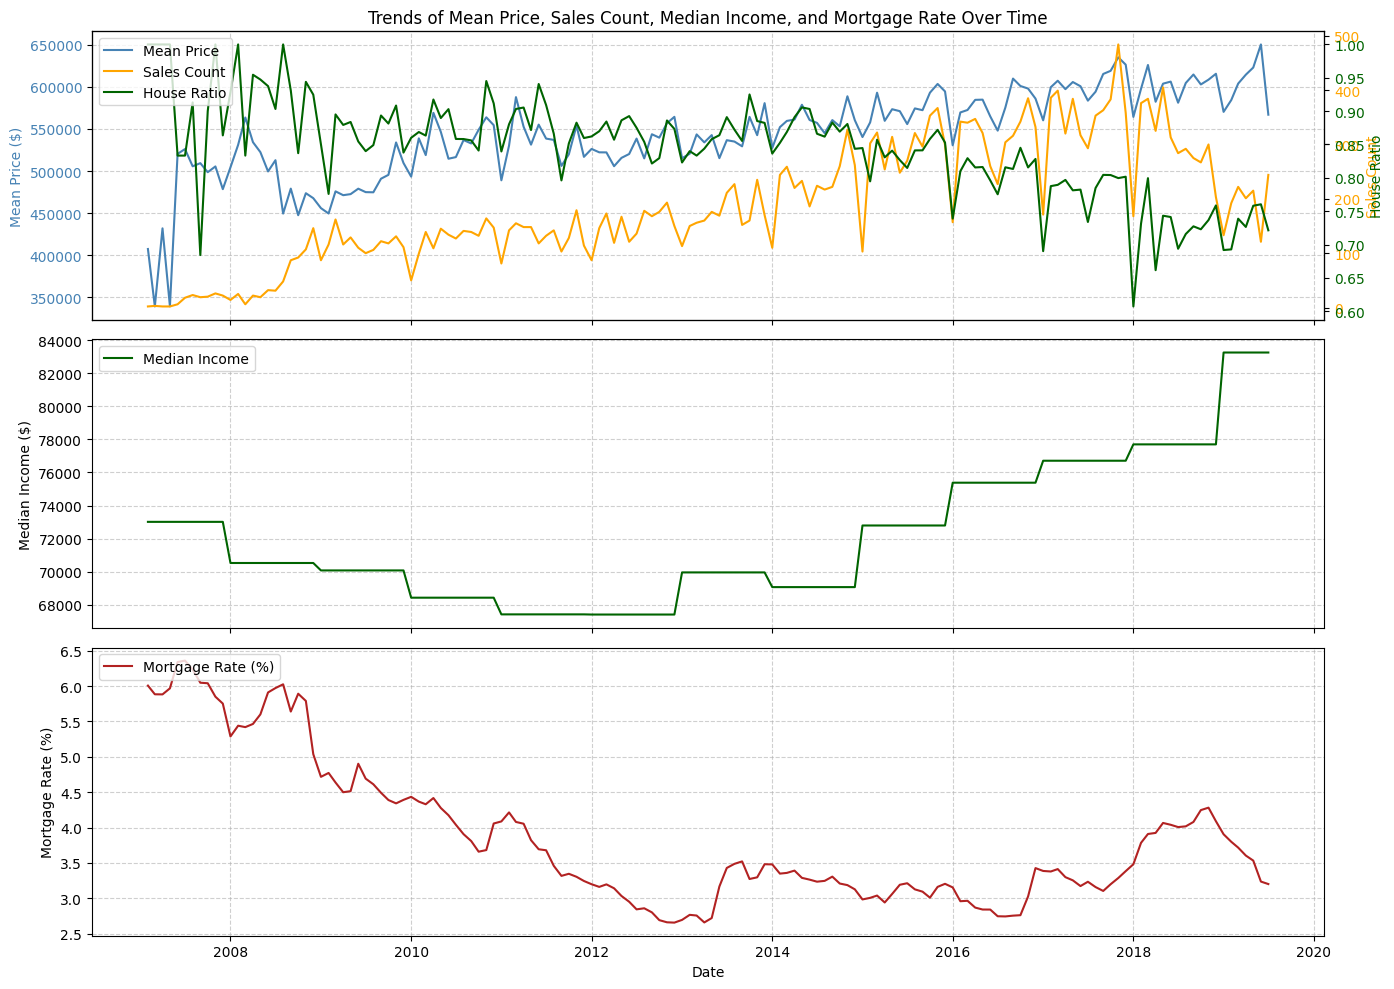

In [55]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot Mean Price and Sales Count
ax1 = axes[0]
ax1.plot(monthly_df.index, monthly_df['price'], color='steelblue', label='Mean Price')
ax1.set_ylabel('Mean Price ($)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_title('Trends of Mean Price, Sales Count, Median Income, and Mortgage Rate Over Time')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(monthly_df.index, monthly_df['sales_count'], color='orange', label='Sales Count')
ax2.set_ylabel('Sales Count', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

ax3 = ax1.twinx()
ax3.plot(monthly_df.index, monthly_df['house_ratio'], color='darkgreen', label='House Ratio')
ax3.set_ylabel('House Ratio', color='darkgreen')
ax3.tick_params(axis='y', labelcolor='darkgreen')

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax3.legend(lines + lines2 + lines3, labels + labels2 + labels3, loc='upper left')

# Plot Median Income
axes[1].plot(monthly_df.index, monthly_df['median_income'], color='darkgreen', label='Median Income')
axes[1].set_ylabel('Median Income ($)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='upper left')

# Plot Mortgage Rate
axes[2].plot(monthly_df.index, monthly_df['mortgage_rate'], color='firebrick', label='Mortgage Rate (%)')
axes[2].set_ylabel('Mortgage Rate (%)')
axes[2].set_xlabel('Date')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.savefig('./imgs/macro_trends_over_time_with_sales.png', dpi=150, bbox_inches='tight')
plt.show()